In [1]:
import pyspark
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.functions import col, explode, regexp_extract
from pyspark.sql.types import StructType, ArrayType, StringType, LongType, DoubleType, BooleanType
from pyspark.sql.functions import udf
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.regression import GBTRegressor
from pyspark.ml.regression import LinearRegression
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.regression import DecisionTreeRegressor
from pyspark.ml.regression import GeneralizedLinearRegression
from pyspark.ml.feature import VectorAssembler

!pip install pyspark

import matplotlib.pyplot as plt
import pandas as pd
import requests
import json
import math
import geopandas as gpd
import os
import pyproj
import datetime
import folium

In [2]:

# Stop any existing SparkSession to avoid conflicts
if 'spark' in locals() and spark is not None:
    spark.stop()

spark = SparkSession.builder.appName("ColabSparkSession").getOrCreate()
print(spark.version)
spark

4.0.2


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:


def haversine_km(lat1, lon1, lat2, lon2):
    # Radius of the Earth in km
    R = 6371.0

    # Convert degrees to radians
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)

    # Haversine formula
    a = math.sin(dphi / 2.0)**2 + math.cos(phi1) * math.cos(phi2) * math.sin(dlambda / 2.0)**2
    c = 2.0 * math.atan2(math.sqrt(a), math.sqrt(1.0 - a))

    return R * c

# Register as a Spark UDF
haversine_km_udf = udf(haversine_km, DoubleType())

Get Data

In [7]:

# Define the path to your parquet files
# Assuming 'data' folder is directly under 'MyDrive'
parquet_path = '/content/drive/MyDrive/data/BDA_Project/ride_year=2024'

# Load the parquet files into a Spark DataFrame
ride_df = spark.read.parquet(parquet_path)

# Filter rides to include only months between April (4) and October (10) for both start and end times
ride_df = ride_df.filter(
    (F.month("start_time_ms") >= 4) & (F.month("start_time_ms") <= 10) &
    (F.month("end_time_ms") >= 4) & (F.month("end_time_ms") <= 10)
)

print(f"Loaded and filtered ride_df with {ride_df.count()} rows and {len(ride_df.columns)} columns.")
ride_df.printSchema()
ride_df.show(5)

Loaded and filtered ride_df with 36069658 rows and 18 columns.
root
 |-- end_station_key: string (nullable = true)
 |-- start_station_key: string (nullable = true)
 |-- start_station_name: string (nullable = true)
 |-- start_station_district: string (nullable = true)
 |-- start_station_latitude: double (nullable = true)
 |-- start_station_longitude: double (nullable = true)
 |-- end_station_name: string (nullable = true)
 |-- end_station_district: string (nullable = true)
 |-- end_station_latitude: double (nullable = true)
 |-- end_station_longitude: double (nullable = true)
 |-- start_time_ms: timestamp (nullable = true)
 |-- end_time_ms: timestamp (nullable = true)
 |-- start_station_name_norm: string (nullable = true)
 |-- end_station_name_norm: string (nullable = true)
 |-- start_coord_key: string (nullable = true)
 |-- end_coord_key: string (nullable = true)
 |-- start_canonical_station_id: string (nullable = true)
 |-- end_canonical_station_id: string (nullable = true)

+--------

In [8]:
!pip install geopandas pyogrio

In [9]:


info_url   = "https://gbfs.velobixi.com/gbfs/2-2/en/station_information.json"
status_url = "https://gbfs.velobixi.com/gbfs/2-2/en/station_status.json"

# --- Load Station Information ---
# Define schema for station information to ensure correct parsing
station_info_schema = StructType() \
    .add("station_id", StringType()) \
    .add("external_id", StringType()) \
    .add("name", StringType()) \
    .add("short_name", StringType()) \
    .add("lat", DoubleType()) \
    .add("lon", DoubleType()) \
    .add("rental_methods", ArrayType(StringType())) \
    .add("capacity", LongType()) \
    .add("electric_bike_surcharge_waiver", BooleanType()) \
    .add("is_charging", BooleanType()) \
    .add("eightd_has_key_dispenser", BooleanType()) \
    .add("has_kiosk", BooleanType())

# Fetch JSON content using requests
response_info = requests.get(info_url)
response_info.raise_for_status() # Raise an exception for HTTP errors
info_data = json.loads(response_info.text)
stations_info_list = info_data['data']['stations']

# Create Spark DataFrame from the parsed list of dictionaries
station_info_df = spark.createDataFrame(stations_info_list, schema=station_info_schema)

print(f"Loaded station_info_df with {station_info_df.count()} rows and {len(station_info_df.columns)} columns.")
station_info_df.printSchema()
station_info_df.show(5)

# --- Load Station Status ---
# Define schema for station status
vehicle_type_availability_schema = StructType() \
    .add("vehicle_type_id", StringType()) \
    .add("count", LongType())

station_status_schema = StructType() \
    .add("station_id", StringType()) \
    .add("num_bikes_available", LongType()) \
    .add("num_ebikes_available", LongType()) \
    .add("vehicle_types_available", ArrayType(vehicle_type_availability_schema)) \
    .add("num_bikes_disabled", LongType()) \
    .add("num_docks_available", LongType()) \
    .add("num_docks_disabled", LongType()) \
    .add("is_installed", LongType()) \
    .add("is_renting", LongType()) \
    .add("is_returning", LongType()) \
    .add("last_reported", LongType()) \
    .add("eightd_has_available_keys", BooleanType()) \
    .add("is_charging", BooleanType())

# Fetch JSON content using requests
response_status = requests.get(status_url)
response_status.raise_for_status() # Raise an exception for HTTP errors
status_data = json.loads(response_status.text)
stations_status_list = status_data['data']['stations']

# Create Spark DataFrame from the parsed list of dictionaries
station_status_df = spark.createDataFrame(stations_status_list, schema=station_status_schema)

print(f"Loaded station_status_df with {station_status_df.count()} rows and {len(station_status_df.columns)} columns.")
station_status_df.printSchema()
station_status_df.show(5)

Loaded station_info_df with 792 rows and 12 columns.
root
 |-- station_id: string (nullable = true)
 |-- external_id: string (nullable = true)
 |-- name: string (nullable = true)
 |-- short_name: string (nullable = true)
 |-- lat: double (nullable = true)
 |-- lon: double (nullable = true)
 |-- rental_methods: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- capacity: long (nullable = true)
 |-- electric_bike_surcharge_waiver: boolean (nullable = true)
 |-- is_charging: boolean (nullable = true)
 |-- eightd_has_key_dispenser: boolean (nullable = true)
 |-- has_kiosk: boolean (nullable = true)

+----------+--------------------+--------------------+----------+------------------+------------------+-----------------+--------+------------------------------+-----------+------------------------+---------+
|station_id|         external_id|                name|short_name|               lat|               lon|   rental_methods|capacity|electric_bike_surcharge_waiver|i

In [10]:


# Define the base path
stm_path = '/content/drive/MyDrive/data/BDA_Project/metro_bus/'

def load_shapefile_to_spark(file_name):
    full_path = os.path.join(stm_path, file_name)
    if os.path.exists(full_path):
        # Read using geopandas (this reads .shp, .dbf, .shx, and .prj automatically)
        gdf = gpd.read_file(full_path)
        # Convert geometry to Well-Known Text (WKT) string to be Spark-compatible
        gdf['geometry'] = gdf['geometry'].apply(lambda x: x.wkt if x is not None else None)
        # Convert all columns to string for a safe initial Spark conversion
        return spark.createDataFrame(gdf.astype(str))
    else:
        print(f"Specific file not found: {full_path}")
        return None

# Load Arrets (Stops) and Lignes (Lines) using the verified filenames from the directory list
stm_arrets_df = load_shapefile_to_spark('stm_arrets_sig.shp')
stm_lignes_df = load_shapefile_to_spark('stm_lignes_sig.shp')

if stm_arrets_df:
    print("\nSTM Arrets (Stops) Metadata:")
    stm_arrets_df.show(5)

if stm_lignes_df:
    print("\nSTM Lignes (Routes) Metadata:")
    stm_lignes_df.show(5)

/tmp/ipykernel_6470/745864123.py:13: UserWarning: Geometry column does not contain geometry.
  gdf['geometry'] = gdf['geometry'].apply(lambda x: x.wkt if x is not None else None)
/tmp/ipykernel_6470/745864123.py:13: UserWarning: Geometry column does not contain geometry.
  gdf['geometry'] = gdf['geometry'].apply(lambda x: x.wkt if x is not None else None)



STM Arrets (Stops) Metadata:
+---------+-------+--------------------+--------------------+----------+--------+--------+-------+----------+--------------------+
|stop_code|stop_id|           stop_name|            stop_url|wheelchair|route_id|loc_type|shelter|service_id|            geometry|
+---------+-------+--------------------+--------------------+----------+--------+--------+-------+----------+--------------------+
|    10118|     43|   Station Angrignon|https://www.stm.i...|         1|       1|       0|    nan|       26M|POINT (296733.669...|
|    10118|  43-01|   Station Angrignon|                None|         1|    None|       2|    nan|       26M|POINT (296677.561...|
|    10120|     42|        Station Monk|https://www.stm.i...|         2|       1|       0|    nan|       26M|POINT (297506.817...|
|    10120|  42-01|Station Monk - Éd...|                None|         2|    None|       2|    nan|       26M|POINT (297515.753...|
|    10120|  42-02|Station Monk - Éd...|             

In [11]:

# Extract longitude and latitude from the POINT (X Y) string
# In many GIS systems, X is Longitude and Y is Latitude
stm_arrets_coords_df = stm_arrets_df.withColumn(
    "longitude",
    regexp_extract(col("geometry"), r"POINT \(([^ ]+) ", 1).cast("double")
).withColumn(
    "latitude",
    regexp_extract(col("geometry"), r" ([^ ]+)\)", 1).cast("double")
)

print("STM Arrets with explicit Latitude and Longitude:")
stm_arrets_coords_df.select("stop_name", "latitude", "longitude").show(5)

STM Arrets with explicit Latitude and Longitude:
+--------------------+-----------------+------------------+
|           stop_name|         latitude|         longitude|
+--------------------+-----------------+------------------+
|   Station Angrignon|5034064.601946615| 296733.6694496935|
|   Station Angrignon|5034048.338108137|  296677.561550543|
|        Station Monk|5034585.077907005| 297506.8170523404|
|Station Monk - Éd...|5034601.625864424|297515.75306016667|
|Station Monk - Éd...|5034568.309883784| 297496.0035076428|
+--------------------+-----------------+------------------+
only showing top 5 rows


In [12]:


# Define the transformation: MTM Zone 8 (EPSG:2950) to WGS84 (EPSG:4326)
# Note: STM data for Montreal usually uses MTM Zone 8
projector = pyproj.Transformer.from_crs("EPSG:2950", "EPSG:4326", always_xy=True)

@udf(returnType=DoubleType())
def transform_x_to_lon(x, y):
    lon, lat = projector.transform(float(x), float(y))
    return lon

@udf(returnType=DoubleType())
def transform_y_to_lat(x, y):
    lon, lat = projector.transform(float(x), float(y))
    return lat

# Apply transformation to get standard GPS coordinates
stm_arrets_gps_df = stm_arrets_coords_df.withColumn(
    "lon_gps", transform_x_to_lon(col("longitude"), col("latitude"))
).withColumn(
    "lat_gps", transform_y_to_lat(col("longitude"), col("latitude"))
)

print("STM Arrets with GPS Coordinates (Decimal Degrees):")
stm_arrets_gps_df.select("stop_name", "lat_gps", "lon_gps").show(5)

STM Arrets with GPS Coordinates (Decimal Degrees):
+--------------------+-----------------+------------------+
|           stop_name|          lat_gps|           lon_gps|
+--------------------+-----------------+------------------+
|   Station Angrignon| 45.4464751328878|-73.60311947733969|
|   Station Angrignon|45.44632813283605|-73.60383647756994|
|        Station Monk|45.45116713406439|-73.59324347436484|
|Station Monk - Éd...|45.45131613409445|-73.59312947433745|
|Station Monk - Éd...|45.45101613403308|-73.59338147440009|
+--------------------+-----------------+------------------+
only showing top 5 rows


Map Live Station IDs to Canonical Station ID (Post Yuchen's Class Resolver)

In [13]:
# Load the mapping CSV to resolve canonical_station_id and station_id
mapping_csv_path = '/content/drive/MyDrive/data/BDA_Project/canonical_live_pairs.csv'

spark_mapping_df = spark.read.csv(mapping_csv_path, header=True, inferSchema=True)

print("Loaded spark_mapping_df:")
spark_mapping_df.show(5)

# 1. Combine Station Information and Station Status with unique columns
# Drop 'is_charging' from status feed as it exists in the info feed
status_cols_to_drop = ['lat', 'lon', 'name', 'capacity', 'is_charging']
status_df_clean = station_status_df.drop(*[c for c in status_cols_to_drop if c in station_status_df.columns])

combined_live_data_df = station_info_df.join(
    status_df_clean,
    on="station_id",
    how="inner"
)

# 2. Prepare a perfectly unique resolver
mapping_ids = spark_mapping_df.select("canonical_station_id", "station_id")

spark_live_resolver_df = mapping_ids.join(
    combined_live_data_df,
    on="station_id",
    how="inner"
)

print("Live resolver prepared with a unique schema:")
spark_live_resolver_df.printSchema()
spark_live_resolver_df.show(5)

Loaded spark_mapping_df:
+--------------------+----------+--------------------+--------+------------------+------------------+--------------------+--------------------+
|canonical_station_id|station_id|                name|capacity|               lat|               lon|        match_method|   match_distance_km|
+--------------------+----------+--------------------+--------+------------------+------------------+--------------------+--------------------+
|            STN_0369|         1|Drummond / de Mai...|      27|  45.4996545106653|-73.57633531093597|     exact_coord_key|                 0.0|
|            STN_0349|         3|     Clark / Ontario|      19|45.510493862520995|-73.56692067715812|exact_normalized_...|0.010889656511468624|
|            STN_0460|         4|du Champ-de-Mars ...|      23| 45.50965520472071|-73.55400860309601|     exact_coord_key|                 0.0|
|            STN_0388|         6|    Ann / Wellington|      15|45.494520387544334|-73.55676591396332|     exact

In [14]:
weather_path = '/content/drive/MyDrive/data/BDA_Project/weather_2023to2025.parquet'

# Load the weather data into a Spark DataFrame
weather_df = spark.read.parquet(weather_path)

print(f"Loaded weather_df with {weather_df.count()} rows and {len(weather_df.columns)} columns.")
weather_df.printSchema()
weather_df.show(5)

Loaded weather_df with 26304 rows and 3 columns.
root
 |-- ts_hour: timestamp_ntz (nullable = true)
 |-- temp: float (nullable = true)
 |-- precip: float (nullable = true)

+-------------------+----+------+
|            ts_hour|temp|precip|
+-------------------+----+------+
|2022-12-31 23:00:00| 2.9|   1.1|
|2023-01-01 00:00:00| 2.8|   1.4|
|2023-01-01 01:00:00|2.85|   0.6|
|2023-01-01 02:00:00| 2.8|   0.7|
|2023-01-01 03:00:00| 2.7|   1.0|
+-------------------+----+------+
only showing top 5 rows


In [15]:
# 1. Ensure the resolver has a strictly unique set of columns
unique_cols = []
seen_names = set()
for name in spark_live_resolver_df.columns:
    if name not in seen_names:
        unique_cols.append(name)
        seen_names.add(name)

clean_resolver_df = spark_live_resolver_df.select(*unique_cols)

# 2. Helper to create a unique prefix for columns to avoid join ambiguity
def prefix_df_cols(df, prefix):
    return df.select([F.col(c).alias(prefix + c) for c in df.columns])

# Prepare clean, uniquely named resolvers
start_res_clean = prefix_df_cols(clean_resolver_df, "start_live_")
end_res_clean = prefix_df_cols(clean_resolver_df, "end_live_")

# Join rides with START station info
final_ride_df = ride_df.join(
    start_res_clean,
    ride_df.start_canonical_station_id == start_res_clean.start_live_canonical_station_id,
    "left"
).drop("start_live_canonical_station_id")

# Join rides with END station info
final_ride_df = final_ride_df.join(
    end_res_clean,
    final_ride_df.end_canonical_station_id == end_res_clean.end_live_canonical_station_id,
    "left"
).drop("end_live_canonical_station_id")

print(f"Joined ride_df with unique resolver columns. Total columns: {len(final_ride_df.columns)}")

Joined ride_df with unique resolver columns. Total columns: 64


In [16]:


# 1. Prepare unique Bixi stations with their coordinates
bixi_stations = spark_live_resolver_df.select(
    F.col("canonical_station_id"),
    F.col("lat").alias("bixi_lat"),
    F.col("lon").alias("bixi_lon"),
    F.col("capacity")
).distinct()

# 2. Spatial Join for Transit Proximity
transit_nodes = stm_arrets_gps_df.select(
    F.col("stop_id"),
    F.col("lat_gps").alias("trans_lat"),
    F.col("lon_gps").alias("trans_lon")
)

# Cross join to calculate distances using the haversine_km_udf
station_transit_dist = bixi_stations.crossJoin(transit_nodes) \
    .withColumn("dist_km", haversine_km_udf(F.col("bixi_lat"), F.col("bixi_lon"), F.col("trans_lat"), F.col("trans_lon")))

# Aggregate transit features per Bixi station with 200m, 500m, and 1km thresholds
spatial_features = station_transit_dist.groupBy("canonical_station_id") \
    .agg(
        F.min("dist_km").alias("dist_to_nearest_transit"),
        F.count(F.when(F.col("dist_km") <= 0.2, 1)).alias("stops_within_200m"),
        F.count(F.when(F.col("dist_km") <= 0.5, 1)).alias("stops_within_500m"),
        F.count(F.when(F.col("dist_km") <= 1.0, 1)).alias("stops_within_1km")
    )

print("Spatial transit features (200m, 500m, 1km) engineered successfully.")
spatial_features.show(5)

Spatial transit features (200m, 500m, 1km) engineered successfully.
+--------------------+-----------------------+-----------------+-----------------+----------------+
|canonical_station_id|dist_to_nearest_transit|stops_within_200m|stops_within_500m|stops_within_1km|
+--------------------+-----------------------+-----------------+-----------------+----------------+
|            STN_0922|    0.07056644342585194|                4|               16|              60|
|            STN_0324|     0.0258094505379296|                3|               20|              82|
|            STN_0954|    0.32047069004548956|                0|               10|              69|
|            STN_0354|   0.033555213590523096|                7|               24|              70|
|            STN_0435|    0.08869979377681182|                6|               54|             105|
+--------------------+-----------------------+-----------------+-----------------+----------------+
only showing top 5 rows


In [17]:
final_ride_df = final_ride_df.filter(
    (final_ride_df.start_canonical_station_id == "STN_0001") & \
    (final_ride_df.end_canonical_station_id == "STN_0001")
)

print(f"Filtered ride_df has {final_ride_df.count()} rows.")
final_ride_df.show(5)

Filtered ride_df has 5809 rows.
+--------------------+--------------------+--------------------+----------------------+----------------------+-----------------------+--------------------+--------------------+--------------------+---------------------+-------------------+-------------------+-----------------------+---------------------+--------------------+--------------------+--------------------------+------------------------+---------------------+----------------------+--------------------+---------------------+--------------+--------------+-------------------------+-------------------+-----------------------------------------+----------------------+-----------------------------------+--------------------+------------------------------+-------------------------------+----------------------------------+-----------------------------+------------------------------+-----------------------------+-----------------------+---------------------+-----------------------+------------------------

In [16]:


# Define the evaluators for each metric
evaluator_rmse = RegressionEvaluator(labelCol="net_flow", predictionCol="prediction", metricName="rmse")
evaluator_mae  = RegressionEvaluator(labelCol="net_flow", predictionCol="prediction", metricName="mae")
evaluator_r2   = RegressionEvaluator(labelCol="net_flow", predictionCol="prediction", metricName="r2")

print("Evaluators defined: evaluator_rmse, evaluator_mae, evaluator_r2")

Evaluators defined: evaluator_rmse, evaluator_mae, evaluator_r2


In [18]:
# 3. Aggregate Rides into Hourly Net Flow
# Calculate Departures (Out) and Arrivals (In)
out_flow = final_ride_df.groupBy("start_canonical_station_id", F.window("start_time_ms", "1 hour")) \
    .count().withColumnRenamed("count", "out_count")

in_flow = final_ride_df.groupBy("end_canonical_station_id", F.window("end_time_ms", "1 hour")) \
    .count().withColumnRenamed("count", "in_count")

# Join Flows
hourly_flow = out_flow.join(
    in_flow,
    (out_flow.start_canonical_station_id == in_flow.end_canonical_station_id) & (out_flow.window == in_flow.window),
    "full"
).select(
    F.coalesce(col("start_canonical_station_id"), col("end_canonical_station_id")).alias("station_id"),
    F.coalesce(out_flow.window.start, in_flow.window.start).alias("hour_timestamp"),
    F.coalesce(col("out_count"), F.lit(0)).alias("departures"),
    F.coalesce(col("in_count"), F.lit(0)).alias("arrivals")
)

hourly_flow = hourly_flow.withColumn("net_flow", col("arrivals") - col("departures"))

In [19]:


# 1. Join Spatial Transit Features
final_ride_features_df = final_ride_df.join(
    spatial_features.alias("spatial"),
    final_ride_df.start_canonical_station_id == F.col("spatial.canonical_station_id"),
    "left"
).drop(F.col("spatial.canonical_station_id"))

# 2. Hourly Flow Aggregation
out_flow = final_ride_features_df.groupBy("start_canonical_station_id", F.window("start_time_ms", "1 hour")) \
    .count().withColumnRenamed("count", "departures")

in_flow = final_ride_features_df.groupBy("end_canonical_station_id", F.window("end_time_ms", "1 hour")) \
    .count().withColumnRenamed("count", "arrivals")

hourly_flow_df = out_flow.join(
    in_flow,
    (out_flow.start_canonical_station_id == in_flow.end_canonical_station_id) & (out_flow.window == in_flow.window),
    "full"
).select(
    F.coalesce(F.col("start_canonical_station_id"), F.col("end_canonical_station_id")).alias("canonical_station_id"),
    F.coalesce(out_flow.window.start, in_flow.window.start).alias("hour_timestamp"),
    F.coalesce(F.col("departures"), F.lit(0)).alias("departures"),
    F.coalesce(F.col("arrivals"), F.lit(0)).alias("arrivals")
)

hourly_flow_df = hourly_flow_df.withColumn("net_flow", F.col("arrivals") - F.col("departures"))

# 3. Apply Lags for arrivals, departures, AND net_flow at specific intervals
w_station = Window.partitionBy("canonical_station_id").orderBy("hour_timestamp")
specific_lags = [1, 2, 4, 6, 12, 24, 48]

for l in specific_lags:
    hourly_flow_df = hourly_flow_df.withColumn(f"arrivals_lag{l}", F.lag("arrivals", l).over(w_station))
    hourly_flow_df = hourly_flow_df.withColumn(f"departures_lag{l}", F.lag("departures", l).over(w_station))
    hourly_flow_df = hourly_flow_df.withColumn(f"net_flow_lag{l}", F.lag("net_flow", l).over(w_station))

print("Requested arrival, departure, and net flow lags engineered successfully.")
hourly_flow_df.show(5)

Requested arrival, departure, and net flow lags engineered successfully.
+--------------------+-------------------+----------+--------+--------+-------------+---------------+-------------+-------------+---------------+-------------+-------------+---------------+-------------+-------------+---------------+-------------+--------------+----------------+--------------+--------------+----------------+--------------+--------------+----------------+--------------+
|canonical_station_id|     hour_timestamp|departures|arrivals|net_flow|arrivals_lag1|departures_lag1|net_flow_lag1|arrivals_lag2|departures_lag2|net_flow_lag2|arrivals_lag4|departures_lag4|net_flow_lag4|arrivals_lag6|departures_lag6|net_flow_lag6|arrivals_lag12|departures_lag12|net_flow_lag12|arrivals_lag24|departures_lag24|net_flow_lag24|arrivals_lag48|departures_lag48|net_flow_lag48|
+--------------------+-------------------+----------+--------+--------+-------------+---------------+-------------+-------------+---------------+----

In [20]:



# 1. Update Trip-Level features to safely handle zero capacity
final_ride_features_safe_df = final_ride_features_df.withColumn(
    "start_congestion_ratio",
    F.when(F.col("start_live_capacity") > 0, F.lit(1) / F.col("start_live_capacity")).otherwise(0)
)

# 2. Aggregate Trip-Level Congestion to Hourly level
hourly_congestion = final_ride_features_safe_df.groupBy(
    "start_canonical_station_id",
    F.window("start_time_ms", "1 hour")
).agg(F.avg("start_congestion_ratio").alias("avg_congestion_ratio")) \
.select(
    F.col("start_canonical_station_id").alias("canonical_station_id"),
    F.col("window.start").alias("hour_timestamp"),
    "avg_congestion_ratio"
)

# 3. Engineer Volume Features (Daily and Monthly Rides)
daily_rides = final_ride_features_safe_df.groupBy(
    "start_canonical_station_id",
    F.date_trunc("day", "start_time_ms").alias("date")
).count().withColumnRenamed("count", "daily_ride_count")

monthly_rides = final_ride_features_safe_df.groupBy(
    "start_canonical_station_id",
    F.date_trunc("month", "start_time_ms").alias("month_date")
).count().withColumnRenamed("count", "monthly_ride_count")

# 4. Join everything into the Model DataFrame
model_df = hourly_flow_df.join(
    hourly_congestion,
    on=["canonical_station_id", "hour_timestamp"],
    how="left"
).join(
    clean_resolver_df.select(F.col("canonical_station_id"), F.col("capacity")),
    on="canonical_station_id",
    how="inner"
).join(
    spatial_features,
    on="canonical_station_id",
    how="inner"
)

model_df = model_df.withColumn("date_link", F.date_trunc("day", "hour_timestamp")) \
    .withColumn("month_link", F.date_trunc("month", "hour_timestamp"))

model_df = model_df.join(daily_rides, (model_df.canonical_station_id == daily_rides.start_canonical_station_id) & (model_df.date_link == daily_rides.date), "left") \
    .drop("start_canonical_station_id", "date") \
    .join(monthly_rides, (model_df.canonical_station_id == monthly_rides.start_canonical_station_id) & (model_df.month_link == monthly_rides.month_date), "left") \
    .drop("start_canonical_station_id", "month_date", "date_link", "month_link")

# 5. Temporal features
model_df = model_df.withColumn("hour", F.hour("hour_timestamp")) \
    .withColumn("day_of_week", F.dayofweek("hour_timestamp")) \
    .withColumn("month", F.month("hour_timestamp")) \
    .withColumn("is_weekend", F.when(F.dayofweek("hour_timestamp").isin(1, 7), 1).otherwise(0)) \
    .fillna(0)



In [21]:


# Select relevant columns from weather_df and rename for clarity in join
weather_processed_df = weather_df.select(
    F.col("ts_hour").alias("weather_hour_timestamp"),
    F.col("temp").alias("weather_temperature"),
    F.col("precip").alias("weather_precipitation")
)

# Join the weather data with the model_df based on the hourly timestamp.
# Assuming weather data is general and not station-specific, as no station_id is present in weather_df.
model_df_with_weather = model_df.join(
    weather_processed_df,
    model_df.hour_timestamp == weather_processed_df.weather_hour_timestamp,
    "left"
)

print(f"Model DataFrame with weather features has {model_df_with_weather.count()} rows and {len(model_df_with_weather.columns)} columns.")
model_df_with_weather.printSchema()
model_df_with_weather.show(5)

Model DataFrame with weather features has 4222 rows and 41 columns.
root
 |-- canonical_station_id: string (nullable = true)
 |-- hour_timestamp: timestamp (nullable = true)
 |-- departures: long (nullable = false)
 |-- arrivals: long (nullable = false)
 |-- net_flow: long (nullable = false)
 |-- arrivals_lag1: long (nullable = true)
 |-- departures_lag1: long (nullable = true)
 |-- net_flow_lag1: long (nullable = true)
 |-- arrivals_lag2: long (nullable = true)
 |-- departures_lag2: long (nullable = true)
 |-- net_flow_lag2: long (nullable = true)
 |-- arrivals_lag4: long (nullable = true)
 |-- departures_lag4: long (nullable = true)
 |-- net_flow_lag4: long (nullable = true)
 |-- arrivals_lag6: long (nullable = true)
 |-- departures_lag6: long (nullable = true)
 |-- net_flow_lag6: long (nullable = true)
 |-- arrivals_lag12: long (nullable = true)
 |-- departures_lag12: long (nullable = true)
 |-- net_flow_lag12: long (nullable = true)
 |-- arrivals_lag24: long (nullable = true)
 |-- 

Check Why Weather not joined correctly

In [22]:


# Get min/max timestamps from model_df_with_weather
model_min_ts = model_df_with_weather.agg(F.min("hour_timestamp")).collect()[0][0]
model_max_ts = model_df_with_weather.agg(F.max("hour_timestamp")).collect()[0][0]

# Get min/max timestamps from weather_df
weather_min_ts = weather_df.agg(F.min("ts_hour")).collect()[0][0]
weather_max_ts = weather_df.agg(F.max("ts_hour")).collect()[0][0]

print(f"Model DataFrame hour_timestamp range: {model_min_ts} to {model_max_ts}")
print(f"Weather DataFrame ts_hour range:      {weather_min_ts} to {weather_max_ts}")

Model DataFrame hour_timestamp range: 2023-04-12 17:00:00 to 2025-10-31 22:00:00
Weather DataFrame ts_hour range:      2022-12-31 23:00:00 to 2025-12-31 22:00:00


In [23]:

# 1. Get coordinates for STN_0001
target_stn = "STN_0001"
stn_coords = bixi_stations.filter(F.col("canonical_station_id") == target_stn).select("bixi_lat", "bixi_lon").first()
target_lat, target_lon = stn_coords["bixi_lat"], stn_coords["bixi_lon"]

# 2. Calculate distance from STN_0001 to all other stations
neighbors_df = bixi_stations.filter(F.col("canonical_station_id") != target_stn) \
    .withColumn("dist_to_target", haversine_km_udf(F.lit(target_lat), F.lit(target_lon), F.col("bixi_lat"), F.col("bixi_lon"))) \
    .orderBy("dist_to_target") \
    .limit(5)

# Collect IDs for filtering
neighbor_ids = [row['canonical_station_id'] for row in neighbors_df.collect()]
cluster_ids = [target_stn] + neighbor_ids

print(f"Target Station: {target_stn}")
print("Nearest 5 Neighbors:")
neighbors_df.select("canonical_station_id", "dist_to_target").show()

Target Station: STN_0001
Nearest 5 Neighbors:
+--------------------+-------------------+
|canonical_station_id|     dist_to_target|
+--------------------+-------------------+
|            STN_0086| 0.1553943694554939|
|            STN_0116| 0.2567165672591107|
|            STN_1060| 0.3005943803531791|
|            STN_0293|0.32018610453251184|
|            STN_0210|0.34946682617296687|
+--------------------+-------------------+



In [24]:


# Create a map centered on the target station
m = folium.Map(location=[target_lat, target_lon], zoom_start=15)

# Add marker for STN_0001
folium.Marker(
    [target_lat, target_lon],
    popup="Target: STN_0001",
    icon=folium.Icon(color="red", icon="info-sign")
).add_to(m)

# Add markers for neighbors
for row in neighbors_df.collect():
    folium.Marker(
        [row['bixi_lat'], row['bixi_lon']],
        popup=f"Neighbor: {row['canonical_station_id']} ({row['dist_to_target']:.3f} km)",
        icon=folium.Icon(color="blue")
    ).add_to(m)

display(m)

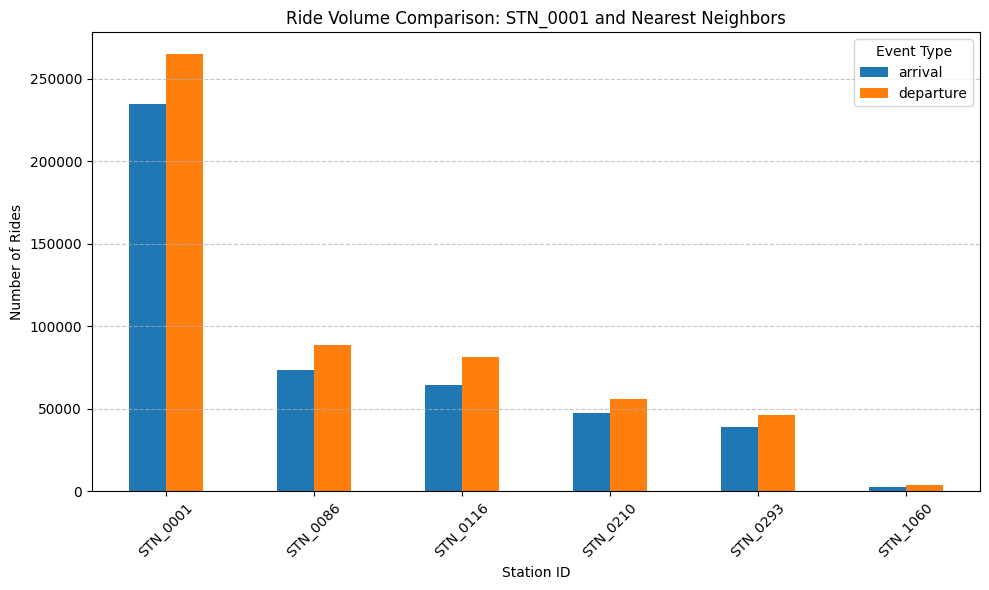

In [25]:

# Aggregate total traffic for the cluster
cluster_traffic = ride_df.filter(F.col("start_canonical_station_id").isin(cluster_ids) | F.col("end_canonical_station_id").isin(cluster_ids)) \
    .select(
        F.explode(F.array(
            F.struct(F.col("start_canonical_station_id").alias("stn"), F.lit("departure").alias("type")),
            F.struct(F.col("end_canonical_station_id").alias("stn"), F.lit("arrival").alias("type"))
        )).alias("event")
    ) \
    .filter(F.col("event.stn").isin(cluster_ids)) \
    .groupBy("event.stn", "event.type") \
    .count() \
    .toPandas()

# Pivot for plotting
plot_data = cluster_traffic.pivot(index='stn', columns='type', values='count').fillna(0)

plot_data.plot(kind='bar', figsize=(10, 6))
plt.title(f"Ride Volume Comparison: {target_stn} and Nearest Neighbors")
plt.ylabel("Number of Rides")
plt.xlabel("Station ID")
plt.xticks(rotation=45)
plt.legend(title="Event Type")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

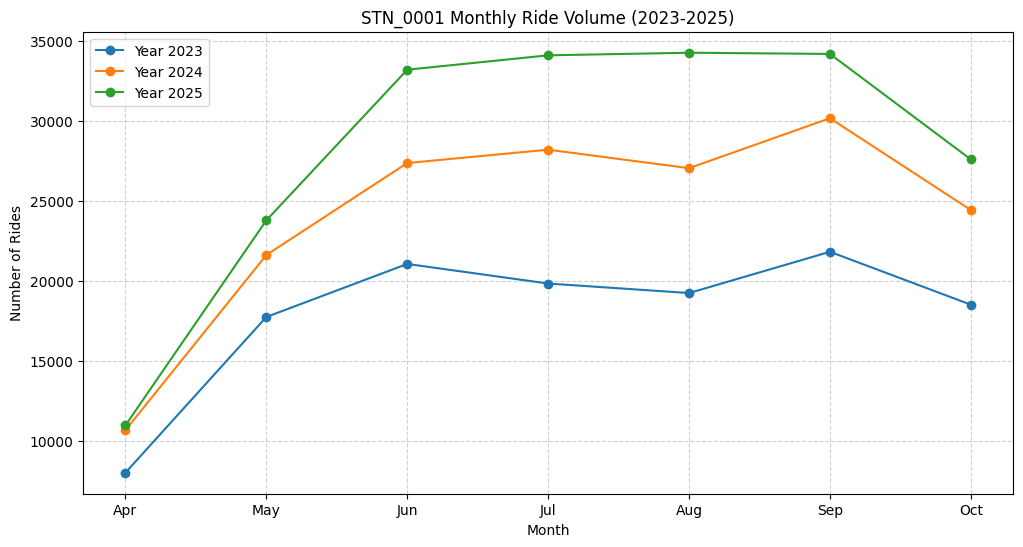

In [26]:


# Filter for STN_0001 only and extract year/month
stn_rides = ride_df.filter((F.col("start_canonical_station_id") == "STN_0001") | (F.col("end_canonical_station_id") == "STN_0001")) \
    .withColumn("year", F.year("start_time_ms")) \
    .withColumn("month", F.month("start_time_ms"))

# Aggregate monthly counts per year
monthly_counts = stn_rides.groupBy("year", "month").count().orderBy("year", "month").toPandas()

# Plotting Monthly Comparison
plt.figure(figsize=(12, 6))
for year in [2023, 2024, 2025]:
    year_data = monthly_counts[monthly_counts['year'] == year]
    if not year_data.empty:
        plt.plot(year_data['month'], year_data['count'], marker='o', label=f'Year {year}')

plt.title("STN_0001 Monthly Ride Volume (2023-2025)")
plt.xlabel("Month")
plt.ylabel("Number of Rides")
plt.xticks(range(4, 11), ["Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct"])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

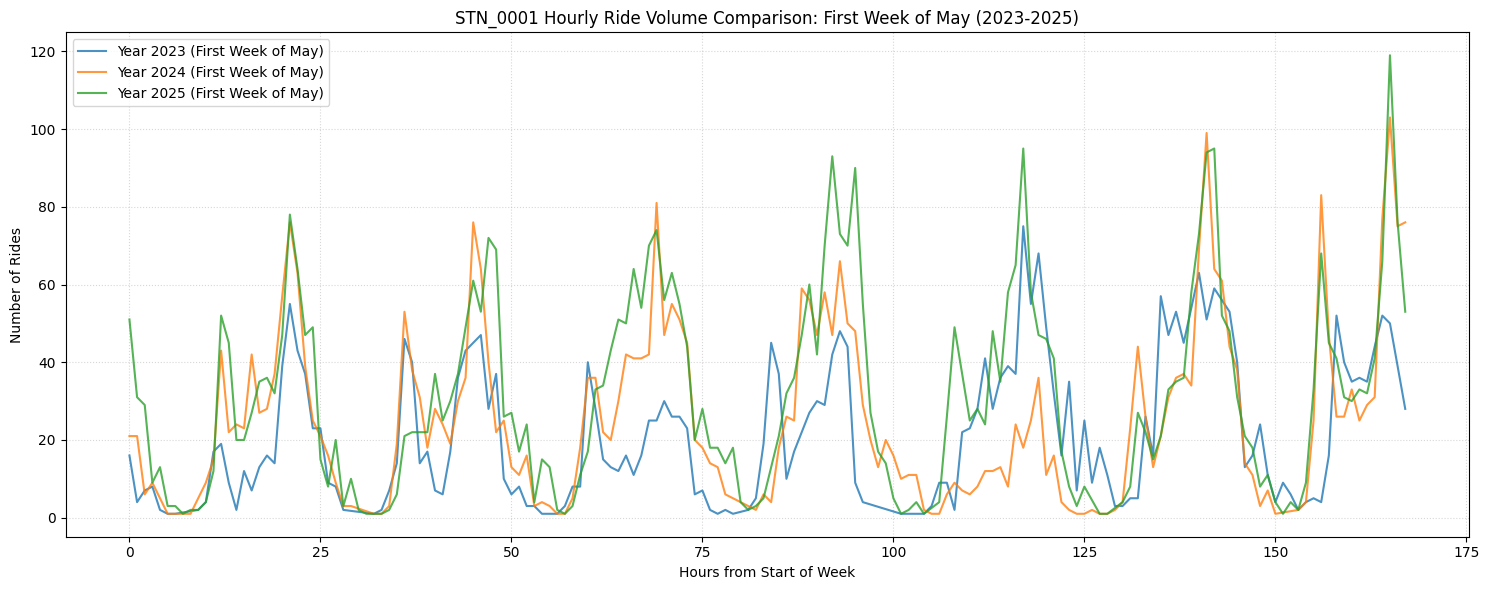

In [28]:
# 1. Identify the first available week (Week of April)
# We'll use day of year or ISO week to align them.
# Let's take the first 7 days of April for each year for a direct alignment.

weekly_comparison = ride_df.filter((F.col("start_canonical_station_id") == "STN_0001") | (F.col("end_canonical_station_id") == "STN_0001")) \
    .withColumn("year", F.year("start_time_ms")) \
    .withColumn("day_of_month", F.dayofmonth("start_time_ms")) \
    .withColumn("hour", F.hour("start_time_ms")) \
    .filter((F.month("start_time_ms") == 5) & (F.col("day_of_month") <= 7))

# Aggregate hourly for the first week
hourly_week_counts = weekly_comparison.groupBy("year", "day_of_month", "hour").count() \
    .withColumn("hour_index", (F.col("day_of_month") - 1) * 24 + F.col("hour")) \
    .orderBy("year", "hour_index").toPandas()

# Plotting Weekly Hourly Profile
plt.figure(figsize=(15, 6))
for year in [2023, 2024, 2025]:
    year_week = hourly_week_counts[hourly_week_counts['year'] == year]
    if not year_week.empty:
        plt.plot(year_week['hour_index'], year_week['count'], label=f'Year {year} (First Week of May)', alpha=0.8)

plt.title("STN_0001 Hourly Ride Volume Comparison: First Week of May (2023-2025)")
plt.xlabel("Hours from Start of Week")
plt.ylabel("Number of Rides")
plt.legend()
plt.grid(True, which='both', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

In [22]:
# 6. Time-based 80/20 Split
# Convert timestamp to numeric to find the 80th percentile cutoff
model_with_ts_numeric = model_df.withColumn("ts_double", F.col("hour_timestamp").cast("double"))
split_date_numeric = model_with_ts_numeric.approxQuantile("ts_double", [0.8], 0.01)[0]
split_timestamp = datetime.datetime.fromtimestamp(split_date_numeric)

print(f"Cutoff date for 80% training data: {split_timestamp}")

train_df = model_df.filter(F.col("hour_timestamp") < split_timestamp)
test_df = model_df.filter(F.col("hour_timestamp") >= split_timestamp)

print(f"Data ready. Total rows: {model_df.count()}")
print(f"Training set: {train_df.count()} rows")
print(f"Testing set: {test_df.count()} rows")

Cutoff date for 80% training data: 2025-07-13 01:00:00
Data ready. Total rows: 4222
Training set: 3337 rows
Testing set: 885 rows


Model Training - To Try All types of Time Series Regression supported by Spark

GBT Regressor

In [23]:

# 1. Define the complete set of features
lag_features = []
specific_lags = [1, 2, 4, 6, 12, 24, 48]
for l in specific_lags:
    lag_features.extend([f"arrivals_lag{l}", f"departures_lag{l}", f"net_flow_lag{l}"])

# We use the DataFrame that contains the joined weather data
# And we handle missing weather values to prevent the VectorAssembler from skipping rows
model_ready_df = model_df_with_weather.fillna({"weather_temperature": 0.0, "weather_precipitation": 0.0})

# Re-apply the split to the weather-aware DataFrame
train_data_final = model_ready_df.filter(F.col("hour_timestamp") < split_timestamp)
test_data_final = model_ready_df.filter(F.col("hour_timestamp") >= split_timestamp)

feature_cols = [
    "dist_to_nearest_transit", "stops_within_200m", "stops_within_500m", "stops_within_1km",
    "hour", "day_of_week", "month", "is_weekend",
    "avg_congestion_ratio", "capacity",
    "daily_ride_count", "monthly_ride_count", "weather_temperature", "weather_precipitation"
] + lag_features

print(f"Total features identified: {len(feature_cols)}")

# 2. Vectorize and Train
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features", handleInvalid="skip")
train_data = assembler.transform(train_data_final)
test_data = assembler.transform(test_data_final)

# Train Separate Outflow and Inflow models
gbt_out = GBTRegressor(featuresCol="features", labelCol="departures", maxIter=10)
gbt_model_out = gbt_out.fit(train_data)

gbt_in = GBTRegressor(featuresCol="features", labelCol="arrivals", maxIter=10)
gbt_model_in = gbt_in.fit(train_data)

print("Models trained successfully with weather features.")

Total features identified: 35
Models trained successfully with weather features.


In [24]:
def show_all_importance(model, name):
    print(f"\n--- {name} Model Weights/Importance ---")
    # Check if the model has featureImportances (Trees) or coefficients (Linear)
    if hasattr(model, 'featureImportances'):
        weights = model.featureImportances.toArray()
    elif hasattr(model, 'coefficients'):
        weights = model.coefficients.toArray()
    else:
        print(f"Model type {type(model)} not supported for importance display.")
        return

    # Extract and map to column names, sorting by absolute value
    imps = sorted(zip(feature_cols, weights), key=lambda x: abs(x[1]), reverse=True)
    for f, s in imps:
        print(f"{f:30}: {s:.6f}")

In [25]:


# Define evaluators
eval_rmse = RegressionEvaluator(metricName='rmse')
eval_mae = RegressionEvaluator(metricName='mae')
eval_r2 = RegressionEvaluator(metricName='r2')

# Predictions for Outflow
pred_out = gbt_model_out.transform(test_data)
# Predictions for Inflow
pred_in = gbt_model_in.transform(test_data)

print("--- Outflow Model Metrics ---")
print(f"RMSE: {eval_rmse.setLabelCol('departures').evaluate(pred_out):.4f}")
print(f"MAE : {eval_mae.setLabelCol('departures').evaluate(pred_out):.4f}")
print(f"R2  : {eval_r2.setLabelCol('departures').evaluate(pred_out):.4f}")

print("\n--- Inflow Model Metrics ---")
print(f"RMSE: {eval_rmse.setLabelCol('arrivals').evaluate(pred_in):.4f}")
print(f"MAE : {eval_mae.setLabelCol('arrivals').evaluate(pred_in):.4f}")
print(f"R2  : {eval_r2.setLabelCol('arrivals').evaluate(pred_in):.4f}")

--- Outflow Model Metrics ---
RMSE: 0.7942
MAE : 0.4865
R2  : 0.3036

--- Inflow Model Metrics ---
RMSE: 0.8479
MAE : 0.5397
R2  : 0.1964


In [26]:
# 1. Predict and Combine
pred_out = gbt_model_out.transform(test_data).select("canonical_station_id", "hour_timestamp", "departures", F.col("prediction").alias("pred_out"))
pred_in = gbt_model_in.transform(test_data).select("canonical_station_id", "hour_timestamp", "arrivals", F.col("prediction").alias("pred_in"))

combined_eval = pred_out.join(pred_in, on=["canonical_station_id", "hour_timestamp"])
combined_eval = combined_eval.withColumn("net_flow", F.col("arrivals") - F.col("departures")) \
                             .withColumn("prediction", F.col("pred_in") - F.col("pred_out"))

# 2. Metrics
rmse = evaluator_rmse.evaluate(combined_eval)
mae  = evaluator_mae.evaluate(combined_eval)
r2   = evaluator_r2.evaluate(combined_eval)

print(f"\nCombined Model Performance (Test Set):")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R2  : {r2:.4f}")


Combined Model Performance (Test Set):
RMSE: 0.5210
MAE : 0.3082
R2  : 0.3611


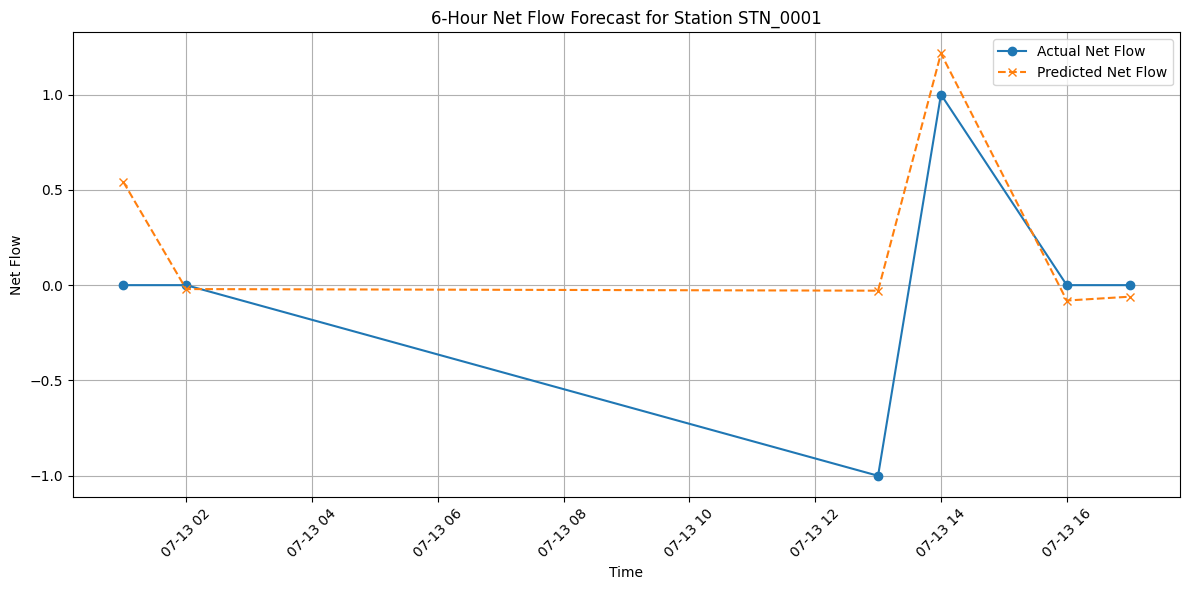

In [27]:

# Pick a sample station and a specific start time from the test set
sample_station = test_df.select("canonical_station_id").first()[0]
# Get the first 6 hours of the test set for this station
forecast_6hr_df = combined_eval.filter(F.col("canonical_station_id") == sample_station) \
    .orderBy("hour_timestamp") \
    .limit(6) \
    .toPandas()

plt.figure(figsize=(12, 6))
plt.plot(forecast_6hr_df['hour_timestamp'], forecast_6hr_df['net_flow'], label='Actual Net Flow', marker='o')
plt.plot(forecast_6hr_df['hour_timestamp'], forecast_6hr_df['prediction'], label='Predicted Net Flow', linestyle='--', marker='x')

plt.title(f'6-Hour Net Flow Forecast for Station {sample_station}')
plt.xlabel('Time')
plt.ylabel('Net Flow')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [28]:

# Ensure predictions are generated
# pred_out and pred_in are already DataFrames from previous successful execution.
# pred_out = gbt_model_out.transform(test_data).select("canonical_station_id", "hour_timestamp", "departures", F.col("prediction").alias("pred_out"))
# pred_in = gbt_model_in.transform(test_data).select("canonical_station_id", "hour_timestamp", "arrivals", F.col("prediction").alias("pred_in"))

# Helper to calculate metrics safely per station
def get_station_metrics(df, target_col, pred_col, prefix):
    # Calculate error
    err_df = df.withColumn("err", F.col(target_col) - F.col(pred_col)) \
               .withColumn("sq_err", F.pow(F.col("err"), 2))

    # Pre-calculate mean per station for R2 calculation
    w = Window.partitionBy("canonical_station_id")
    err_df = err_df.withColumn("mean_target", F.avg(target_col).over(w))
    err_df = err_df.withColumn("sq_tot_var", F.pow(F.col(target_col) - F.col("mean_target"), 2))

    # Aggregate
    metrics = err_df.groupBy("canonical_station_id").agg(
        F.avg(F.abs(F.col("err"))).alias(f"mae_{prefix}"),
        F.sqrt(F.avg(F.col("sq_err"))).alias(f"rmse_{prefix}"),
        F.sum(F.col("sq_err")).alias("ss_res"),
        F.sum(F.col("sq_tot_var")).alias("ss_tot")
    ).withColumn(
        f"r2_{prefix}",
        F.when(F.col("ss_tot") > 0, 1 - (F.col("ss_res") / F.col("ss_tot"))).otherwise(F.lit(None))
    ).drop("ss_res", "ss_tot")

    return metrics

# Calculate metrics
station_metrics_out = get_station_metrics(pred_out, "departures", "pred_out", "out")
station_metrics_in = get_station_metrics(pred_in, "arrivals", "pred_in", "in")

# Join and Show
station_metrics = station_metrics_out.join(station_metrics_in, on="canonical_station_id", how="outer")

print("Station-level metrics for Outflow and Inflow calculated correctly:")
station_metrics.select("canonical_station_id", "mae_out", "rmse_out", "r2_out", "mae_in", "rmse_in", "r2_in").show(10)

Station-level metrics for Outflow and Inflow calculated correctly:
+--------------------+------------------+------------------+-------------------+------------------+-----------------+-------------------+
|canonical_station_id|           mae_out|          rmse_out|             r2_out|            mae_in|          rmse_in|              r2_in|
+--------------------+------------------+------------------+-------------------+------------------+-----------------+-------------------+
|            STN_0001|0.4865033219213689|0.7942313753482988|0.30360971198716036|0.5397485556918501|0.847853867976494|0.19637725309307263|
+--------------------+------------------+------------------+-------------------+------------------+-----------------+-------------------+



In [29]:
# 1. Ensure predictions are generated
pred_out = gbt_model_out.transform(test_data)
pred_in = gbt_model_in.transform(test_data)

# 2. Helper to calculate metrics safely per station
def get_station_metrics(df, target_col, pred_col, prefix):
    # Calculate error
    err_df = df.withColumn("err", F.col(target_col) - F.col(pred_col)) \
               .withColumn("sq_err", F.pow(F.col("err"), 2))

    # Pre-calculate mean per station for R2 calculation
    w = Window.partitionBy("canonical_station_id")
    err_df = err_df.withColumn("mean_target", F.avg(target_col).over(w))
    err_df = err_df.withColumn("sq_tot_var", F.pow(F.col(target_col) - F.col("mean_target"), 2))

    # Aggregate
    metrics = err_df.groupBy("canonical_station_id").agg(
        F.avg(F.abs(F.col("err"))).alias(f"mae_{prefix}"),
        F.sqrt(F.avg(F.col("sq_err"))).alias(f"rmse_{prefix}"),
        F.sum(F.col("sq_err")).alias("ss_res"),
        F.sum(F.col("sq_tot_var")).alias("ss_tot")
    ).withColumn(
        f"r2_{prefix}",
        F.when(F.col("ss_tot") > 0, 1 - (F.col("ss_res") / F.col("ss_tot"))).otherwise(F.lit(None))
    ).drop("ss_res", "ss_tot")

    return metrics

# 3. Calculate metrics
station_metrics_out = get_station_metrics(pred_out, "departures", "prediction", "out")
station_metrics_in = get_station_metrics(pred_in, "arrivals", "prediction", "in")

# 4. Join and Show
station_metrics = station_metrics_out.join(station_metrics_in, on="canonical_station_id", how="outer")

print("Station-level metrics for Outflow and Inflow calculated correctly:")
station_metrics.select("canonical_station_id", "mae_out", "rmse_out", "r2_out", "mae_in", "rmse_in", "r2_in").show(10)

Station-level metrics for Outflow and Inflow calculated correctly:
+--------------------+------------------+------------------+-------------------+------------------+-----------------+-------------------+
|canonical_station_id|           mae_out|          rmse_out|             r2_out|            mae_in|          rmse_in|              r2_in|
+--------------------+------------------+------------------+-------------------+------------------+-----------------+-------------------+
|            STN_0001|0.4865033219213689|0.7942313753482988|0.30360971198716036|0.5397485556918501|0.847853867976494|0.19637725309307263|
+--------------------+------------------+------------------+-------------------+------------------+-----------------+-------------------+



Try predicting actual capacity (cum sum)

In [30]:

# 1. Define window partitioned by station and ordered by time
window_spec = Window.partitionBy("canonical_station_id").orderBy("hour_timestamp")

# Join combined_eval with clean_resolver_df to get capacity
# Make sure to select only necessary columns to avoid duplication and keep the DataFrame tidy
combined_eval_with_capacity = combined_eval.join(
    clean_resolver_df.select("canonical_station_id", "capacity"),
    on="canonical_station_id",
    how="left"
)

# 2. Calculate cumulative net flow (Predicted Inventory Change)
# We use the 'prediction' column from our GBT model to forecast future state
predictions_with_inventory = combined_eval_with_capacity.withColumn(
    "cumulative_net_flow_forecast",
    F.sum("prediction").over(window_spec)
)

# 3. Define a starting point (Initial Bikes)
# In a real scenario, this would be the current 'num_bikes_available'
# For this simulation, let's assume stations start at 50% capacity
predictions_with_inventory = predictions_with_inventory.withColumn(
    "predicted_bikes_available",
    (F.col("capacity") * 0.5) + F.col("cumulative_net_flow_forecast")
)

# 4. Create Refill Flag (e.g., if predicted bikes drop below 10% of capacity)
predictions_with_inventory = predictions_with_inventory.withColumn(
    "refill_required_flag",
    F.when(F.col("predicted_bikes_available") < (F.col("capacity") * 0.1), 1).otherwise(0)
)

print("Cumulative flow and refill flags calculated.")
predictions_with_inventory.select(
    "canonical_station_id",
    "hour_timestamp",
    "prediction",
    "predicted_bikes_available",
    "refill_required_flag"
).show(10)

Cumulative flow and refill flags calculated.
+--------------------+-------------------+--------------------+-------------------------+--------------------+
|canonical_station_id|     hour_timestamp|          prediction|predicted_bikes_available|refill_required_flag|
+--------------------+-------------------+--------------------+-------------------------+--------------------+
|            STN_0001|2025-07-13 01:00:00|  0.5423074014686236|       20.042307401468623|                   0|
|            STN_0001|2025-07-13 02:00:00|-0.02059051256308...|       20.021716888905534|                   0|
|            STN_0001|2025-07-13 13:00:00|-0.02907575724994982|       19.992641131655585|                   0|
|            STN_0001|2025-07-13 14:00:00|   1.215343061150749|       21.207984192806336|                   0|
|            STN_0001|2025-07-13 16:00:00|-0.08077226358654532|        21.12721192921979|                   0|
|            STN_0001|2025-07-13 17:00:00|-0.06062609729083346|    

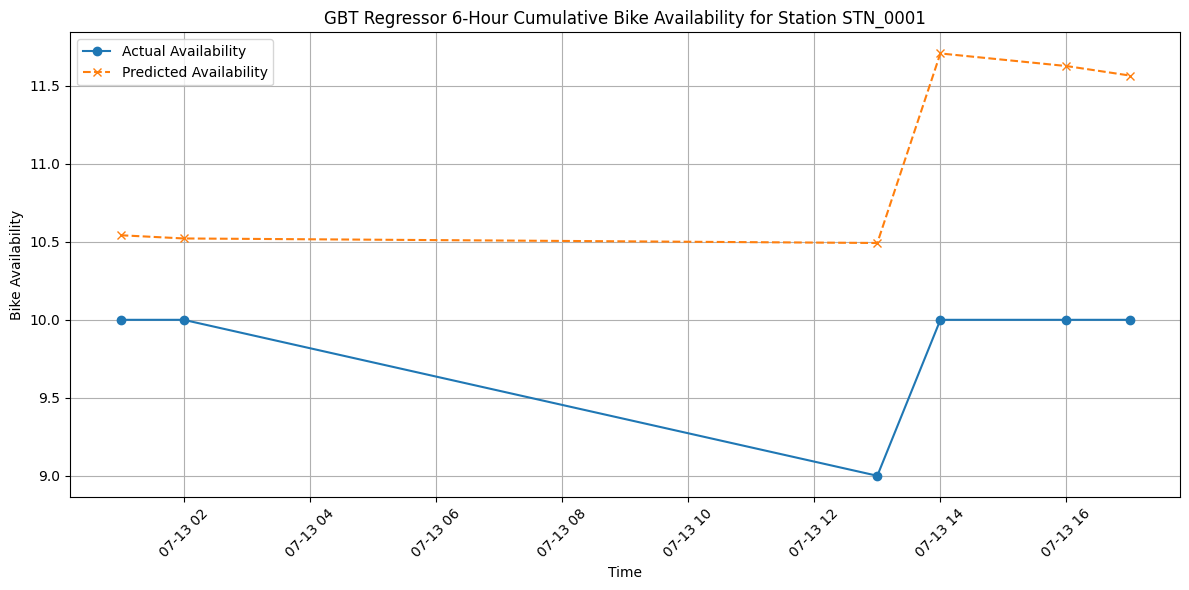

In [31]:
# Pick a sample station
sample_station = test_df.select("canonical_station_id").first()[0]

# Get the first 6 hours of the test set for this station
forecast_6hr_df = combined_eval.filter(F.col("canonical_station_id") == sample_station) \
    .orderBy("hour_timestamp") \
    .limit(6) \
    .toPandas()

# Starting availability
initial_availability = 10

# Compute cumulative actual availability
forecast_6hr_df["actual_availability"] = initial_availability + forecast_6hr_df["net_flow"].cumsum()

# Compute cumulative predicted availability
forecast_6hr_df["predicted_availability"] = initial_availability + forecast_6hr_df["prediction"].cumsum()

# Plot
plt.figure(figsize=(12, 6))
plt.plot(forecast_6hr_df['hour_timestamp'], forecast_6hr_df['actual_availability'],
         label='Actual Availability', marker='o')
plt.plot(forecast_6hr_df['hour_timestamp'], forecast_6hr_df['predicted_availability'],
         label='Predicted Availability', linestyle='--', marker='x')

plt.title(f'GBT Regressor 6-Hour Cumulative Bike Availability for Station {sample_station}')
plt.xlabel('Time')
plt.ylabel('Bike Availability')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Test RF & Linear Regressions

In [32]:


print("--- Training Linear Regression Models ---")
# Linear Regression for Outflow
lr_out = LinearRegression(featuresCol='features', labelCol='departures')
lr_model_out = lr_out.fit(train_data)

# Linear Regression for Inflow
lr_in = LinearRegression(featuresCol='features', labelCol='arrivals')
lr_model_in = lr_in.fit(train_data)

# Predictions
pred_out_lr = lr_model_out.transform(test_data)
pred_in_lr = lr_model_in.transform(test_data)

print("LR Outflow - RMSE:", eval_rmse.setLabelCol('departures').evaluate(pred_out_lr))
print("LR Inflow  - RMSE:", eval_rmse.setLabelCol('arrivals').evaluate(pred_in_lr))

--- Training Linear Regression Models ---
LR Outflow - RMSE: 0.8482929578701318
LR Inflow  - RMSE: 0.8915638427673559


In [33]:

print("--- Training Random Forest Models ---")
# Random Forest for Outflow
rf_out = RandomForestRegressor(featuresCol='features', labelCol='departures', numTrees=20)
rf_model_out = rf_out.fit(train_data)

# Random Forest for Inflow
rf_in = RandomForestRegressor(featuresCol='features', labelCol='arrivals', numTrees=20)
rf_model_in = rf_in.fit(train_data)

# Predictions
pred_out_rf = rf_model_out.transform(test_data)
pred_in_rf = rf_model_in.transform(test_data)

print("RF Outflow - RMSE:", eval_rmse.setLabelCol('departures').evaluate(pred_out_rf))
print("RF Inflow  - RMSE:", eval_rmse.setLabelCol('arrivals').evaluate(pred_in_rf))

--- Training Random Forest Models ---
RF Outflow - RMSE: 0.8294556415307831
RF Inflow  - RMSE: 0.9189705745660387


In [35]:
show_all_importance(gbt_model_out, "GBT Outflow")
show_all_importance(gbt_model_in, "GBT Inflow")
show_all_importance(rf_model_out, "RF Outflow")
show_all_importance(rf_model_in, "RF Inflow")
show_all_importance(lr_model_out, "LR Outflow")
show_all_importance(lr_model_in, "LR Inflow")


--- GBT Outflow Model Weights/Importance ---
avg_congestion_ratio          : 0.279843
arrivals_lag1                 : 0.127159
hour                          : 0.097996
daily_ride_count              : 0.087827
departures_lag1               : 0.058886
arrivals_lag2                 : 0.044088
departures_lag2               : 0.034320
net_flow_lag6                 : 0.031798
arrivals_lag24                : 0.030841
weather_temperature           : 0.028797
arrivals_lag6                 : 0.024228
arrivals_lag4                 : 0.023576
net_flow_lag48                : 0.018802
monthly_ride_count            : 0.018699
weather_precipitation         : 0.013432
departures_lag6               : 0.012282
net_flow_lag4                 : 0.011944
net_flow_lag12                : 0.010717
day_of_week                   : 0.009191
net_flow_lag2                 : 0.008952
net_flow_lag1                 : 0.004765
departures_lag4               : 0.004659
net_flow_lag24                : 0.004152
arrivals_la

In [34]:
def get_metrics(pred, label):
    return [
        eval_rmse.setLabelCol(label).evaluate(pred),
        eval_mae.setLabelCol(label).evaluate(pred),
        eval_r2.setLabelCol(label).evaluate(pred)
    ]

results = [
    ['GBT', 'Outflow'] + get_metrics(pred_out, 'departures'),
    ['GBT', 'Inflow'] + get_metrics(pred_in, 'arrivals'),
    ['LR', 'Outflow'] + get_metrics(pred_out_lr, 'departures'),
    ['LR', 'Inflow'] + get_metrics(pred_in_lr, 'arrivals'),
    ['RF', 'Outflow'] + get_metrics(pred_out_rf, 'departures'),
    ['RF', 'Inflow'] + get_metrics(pred_in_rf, 'arrivals')
]

summary_df = pd.DataFrame(results, columns=['Model', 'Target', 'RMSE', 'MAE', 'R2'])
display(summary_df)

,Model,Target,RMSE,MAE,R2
0,GBT,Outflow,0.794231,0.486503,0.303610
1,GBT,Inflow,0.847854,0.539749,0.196377
2,LR,Outflow,0.848293,0.597991,0.205580
3,LR,Inflow,0.891564,0.624259,0.111382
4,RF,Outflow,0.829456,0.515263,0.240470
5,RF,Inflow,0.918971,0.584607,0.055910


Linear Regression Predictioni Graph

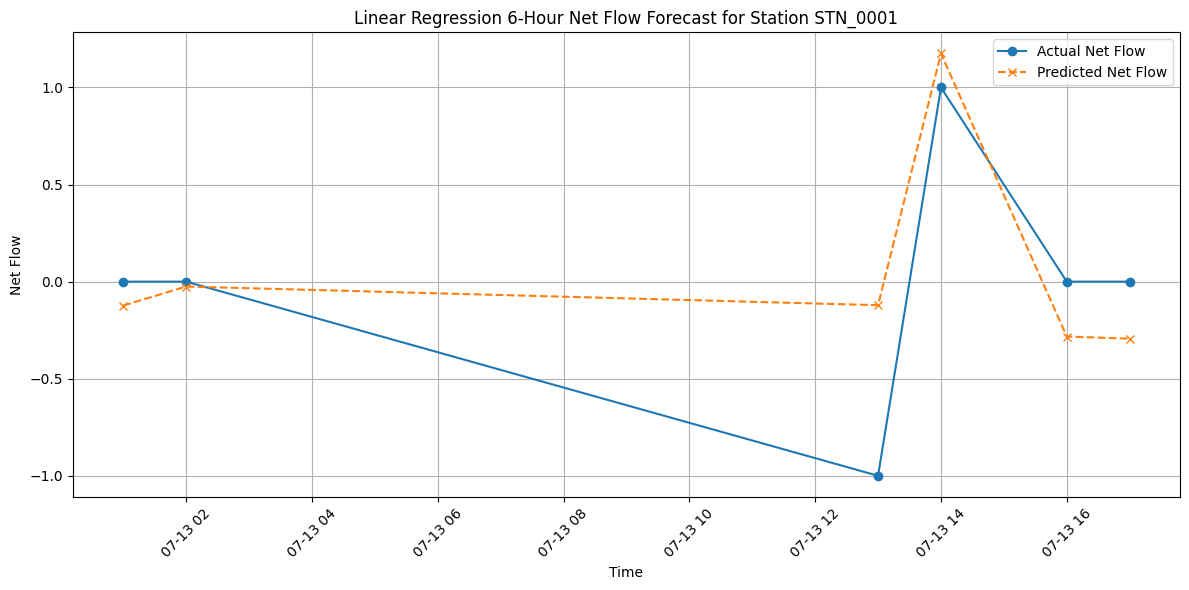

In [36]:

# Fix Ambiguous Reference by selecting unique columns from each side
pred_out_sel = pred_out_lr.select("canonical_station_id", "hour_timestamp", "departures", F.col("prediction").alias("pred_out_lr"))
pred_in_sel = pred_in_lr.select("canonical_station_id", "hour_timestamp", "arrivals", F.col("prediction").alias("pred_in_lr"))

combined_eval_lr = pred_out_sel.join(pred_in_sel, on=["canonical_station_id", "hour_timestamp"])
combined_eval_lr = combined_eval_lr.withColumn("net_flow", F.col("arrivals") - F.col("departures")) \
                             .withColumn("prediction", F.col("pred_in_lr") - F.col("pred_out_lr"))

# Pick a sample station and a specific start time from the test set
sample_station = test_df.select("canonical_station_id").first()[0]
# Get the first 6 hours of the test set for this station
forecast_6hr_df_lr = combined_eval_lr.filter(F.col("canonical_station_id") == sample_station) \
    .orderBy("hour_timestamp") \
    .limit(6) \
    .toPandas()

plt.figure(figsize=(12, 6))
plt.plot(forecast_6hr_df_lr['hour_timestamp'], forecast_6hr_df_lr['net_flow'], label='Actual Net Flow', marker='o')
plt.plot(forecast_6hr_df_lr['hour_timestamp'], forecast_6hr_df_lr['prediction'], label='Predicted Net Flow', linestyle='--', marker='x')

plt.title(f'Linear Regression 6-Hour Net Flow Forecast for Station {sample_station}')
plt.xlabel('Time')
plt.ylabel('Net Flow')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [37]:

# 1. Define window partitioned by station and ordered by time
window_spec = Window.partitionBy("canonical_station_id").orderBy("hour_timestamp")

# Join combined_eval with clean_resolver_df to get capacity
# Make sure to select only necessary columns to avoid duplication and keep the DataFrame tidy
combined_eval_with_capacity_lr = combined_eval_lr.join(
    clean_resolver_df.select("canonical_station_id", "capacity"),
    on="canonical_station_id",
    how="left"
)

# 2. Calculate cumulative net flow (Predicted Inventory Change)
# We use the 'prediction' column from our GBT model to forecast future state
predictions_with_inventory_lr = combined_eval_with_capacity_lr.withColumn(
    "cumulative_net_flow_forecast",
    F.sum("prediction").over(window_spec)
)

# 3. Define a starting point (Initial Bikes)
# In a real scenario, this would be the current 'num_bikes_available'
# For this simulation, let's assume stations start at 50% capacity
predictions_with_inventory_lr = predictions_with_inventory_lr.withColumn(
    "predicted_bikes_available",
    (F.col("capacity") * 0.5) + F.col("cumulative_net_flow_forecast")
)

# 4. Create Refill Flag (e.g., if predicted bikes drop below 10% of capacity)
predictions_with_inventory_lr = predictions_with_inventory_lr.withColumn(
    "refill_required_flag",
    F.when(F.col("predicted_bikes_available") < (F.col("capacity") * 0.1), 1).otherwise(0)
)

print("Cumulative flow and refill flags calculated.")
predictions_with_inventory_lr.select(
    "canonical_station_id",
    "hour_timestamp",
    "prediction",
    "predicted_bikes_available",
    "refill_required_flag"
).show(10)

Cumulative flow and refill flags calculated.
+--------------------+-------------------+--------------------+-------------------------+--------------------+
|canonical_station_id|     hour_timestamp|          prediction|predicted_bikes_available|refill_required_flag|
+--------------------+-------------------+--------------------+-------------------------+--------------------+
|            STN_0001|2025-07-13 01:00:00|-0.12328587832153604|       19.376714121678464|                   0|
|            STN_0001|2025-07-13 02:00:00|-0.02525262210085...|        19.35146149957761|                   0|
|            STN_0001|2025-07-13 13:00:00|-0.12128374448924273|       19.230177755088366|                   0|
|            STN_0001|2025-07-13 14:00:00|  1.1752544298117735|       20.405432184900143|                   0|
|            STN_0001|2025-07-13 16:00:00| -0.2828075574748756|       20.122624627425264|                   0|
|            STN_0001|2025-07-13 17:00:00| -0.2938624004393835|    

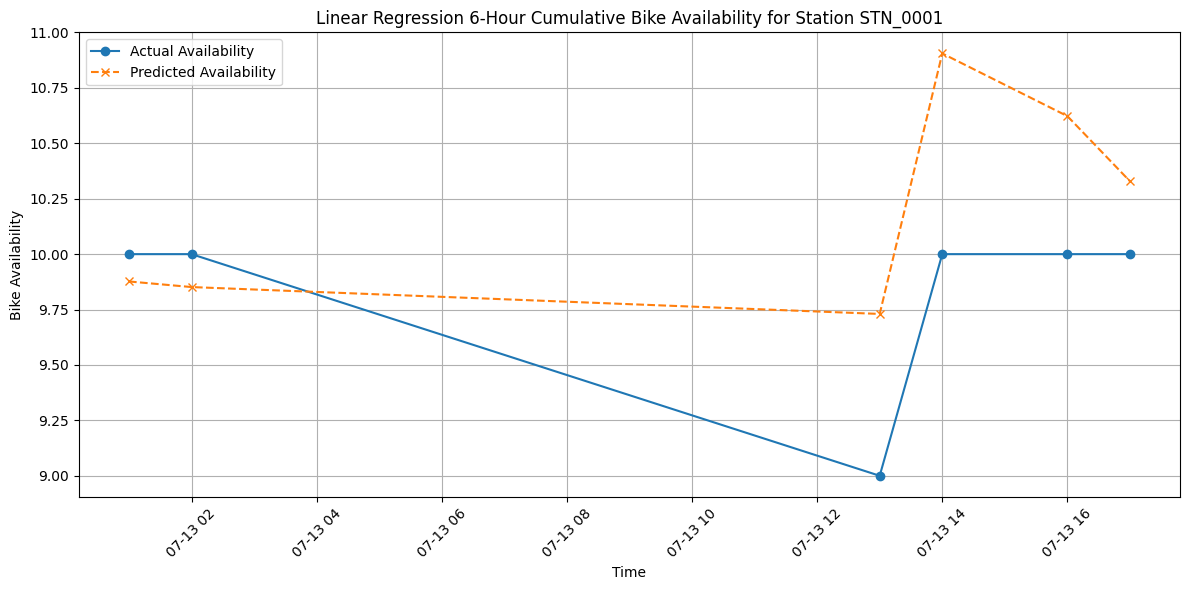

In [38]:

# Pick a sample station
sample_station = test_df.select("canonical_station_id").first()[0]

# Get the first 6 hours of the test set for this station
forecast_6hr_df_lr = combined_eval_lr.filter(F.col("canonical_station_id") == sample_station) \
    .orderBy("hour_timestamp") \
    .limit(6) \
    .toPandas()

# Starting availability
initial_availability = 10

# Compute cumulative actual availability
forecast_6hr_df_lr["actual_availability"] = initial_availability + forecast_6hr_df_lr["net_flow"].cumsum()

# Compute cumulative predicted availability
forecast_6hr_df_lr["predicted_availability"] = initial_availability + forecast_6hr_df_lr["prediction"].cumsum()

# Plot
plt.figure(figsize=(12, 6))
plt.plot(forecast_6hr_df_lr['hour_timestamp'], forecast_6hr_df_lr['actual_availability'],
         label='Actual Availability', marker='o')
plt.plot(forecast_6hr_df_lr['hour_timestamp'], forecast_6hr_df_lr['predicted_availability'],
         label='Predicted Availability', linestyle='--', marker='x')

plt.title(f'Linear Regression 6-Hour Cumulative Bike Availability for Station {sample_station}')
plt.xlabel('Time')
plt.ylabel('Bike Availability')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Random Forest Regressor Prediction Graph

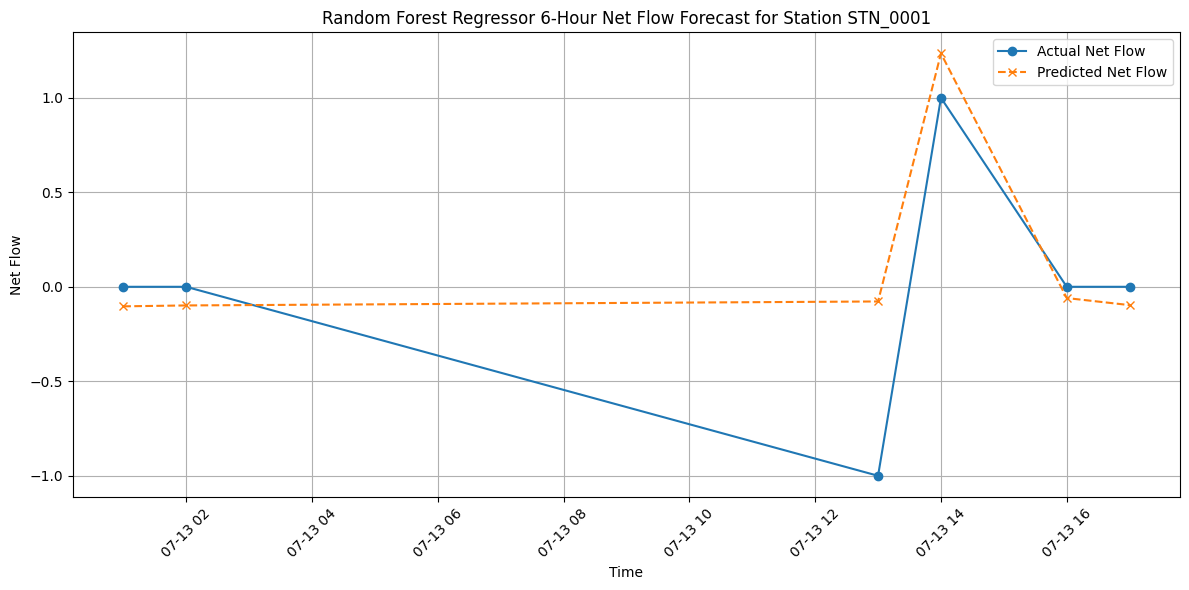

In [40]:
# Fix Ambiguous Reference by selecting unique columns from each side before join
pred_out_rf_sel = pred_out_rf.select("canonical_station_id", "hour_timestamp", "departures", F.col("prediction").alias("pred_out_rf"))
pred_in_rf_sel = pred_in_rf.select("canonical_station_id", "hour_timestamp", "arrivals", F.col("prediction").alias("pred_in_rf"))

combined_eval_rf = pred_out_rf_sel.join(pred_in_rf_sel, on=["canonical_station_id", "hour_timestamp"])
combined_eval_rf = combined_eval_rf.withColumn("net_flow", F.col("arrivals") - F.col("departures")) \
                             .withColumn("prediction", F.col("pred_in_rf") - F.col("pred_out_rf"))

# Pick a sample station and a specific start time from the test set
sample_station = test_df.select("canonical_station_id").first()[0]
# Get the first 6 hours of the test set for this station
forecast_6hr_df_rf = combined_eval_rf.filter(F.col("canonical_station_id") == sample_station) \
    .orderBy("hour_timestamp") \
    .limit(6) \
    .toPandas()

plt.figure(figsize=(12, 6))
plt.plot(forecast_6hr_df_rf['hour_timestamp'], forecast_6hr_df_rf['net_flow'], label='Actual Net Flow', marker='o')
plt.plot(forecast_6hr_df_rf['hour_timestamp'], forecast_6hr_df_rf['prediction'], label='Predicted Net Flow', linestyle='--', marker='x')

plt.title(f'Random Forest Regressor 6-Hour Net Flow Forecast for Station {sample_station}')
plt.xlabel('Time')
plt.ylabel('Net Flow')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [41]:

# 1. Define window partitioned by station and ordered by time
window_spec = Window.partitionBy("canonical_station_id").orderBy("hour_timestamp")

# Join combined_eval with clean_resolver_df to get capacity
# Make sure to select only necessary columns to avoid duplication and keep the DataFrame tidy
combined_eval_with_capacity_rf = combined_eval_rf.join(
    clean_resolver_df.select("canonical_station_id", "capacity"),
    on="canonical_station_id",
    how="left"
)

# 2. Calculate cumulative net flow (Predicted Inventory Change)
# We use the 'prediction' column from our GBT model to forecast future state
predictions_with_inventory_rf = combined_eval_with_capacity_rf.withColumn(
    "cumulative_net_flow_forecast",
    F.sum("prediction").over(window_spec)
)

# 3. Define a starting point (Initial Bikes)
# In a real scenario, this would be the current 'num_bikes_available'
# For this simulation, let's assume stations start at 50% capacity
predictions_with_inventory_rf = predictions_with_inventory_rf.withColumn(
    "predicted_bikes_available",
    (F.col("capacity") * 0.5) + F.col("cumulative_net_flow_forecast")
)

# 4. Create Refill Flag (e.g., if predicted bikes drop below 10% of capacity)
predictions_with_inventory_rf = predictions_with_inventory_rf.withColumn(
    "refill_required_flag",
    F.when(F.col("predicted_bikes_available") < (F.col("capacity") * 0.1), 1).otherwise(0)
)

print("Cumulative flow and refill flags calculated.")
predictions_with_inventory_rf.select(
    "canonical_station_id",
    "hour_timestamp",
    "prediction",
    "predicted_bikes_available",
    "refill_required_flag"
).show(10)

Cumulative flow and refill flags calculated.
+--------------------+-------------------+--------------------+-------------------------+--------------------+
|canonical_station_id|     hour_timestamp|          prediction|predicted_bikes_available|refill_required_flag|
+--------------------+-------------------+--------------------+-------------------------+--------------------+
|            STN_0001|2025-07-13 01:00:00|-0.10340303311318699|        19.39659696688681|                   0|
|            STN_0001|2025-07-13 02:00:00|-0.09865993433141851|       19.297937032555396|                   0|
|            STN_0001|2025-07-13 13:00:00| -0.0776173897462451|       19.220319642809148|                   0|
|            STN_0001|2025-07-13 14:00:00|  1.2347664340033595|        20.45508607681251|                   0|
|            STN_0001|2025-07-13 16:00:00|-0.05959740531090452|       20.395488671501603|                   0|
|            STN_0001|2025-07-13 17:00:00|-0.09695896451074959|    

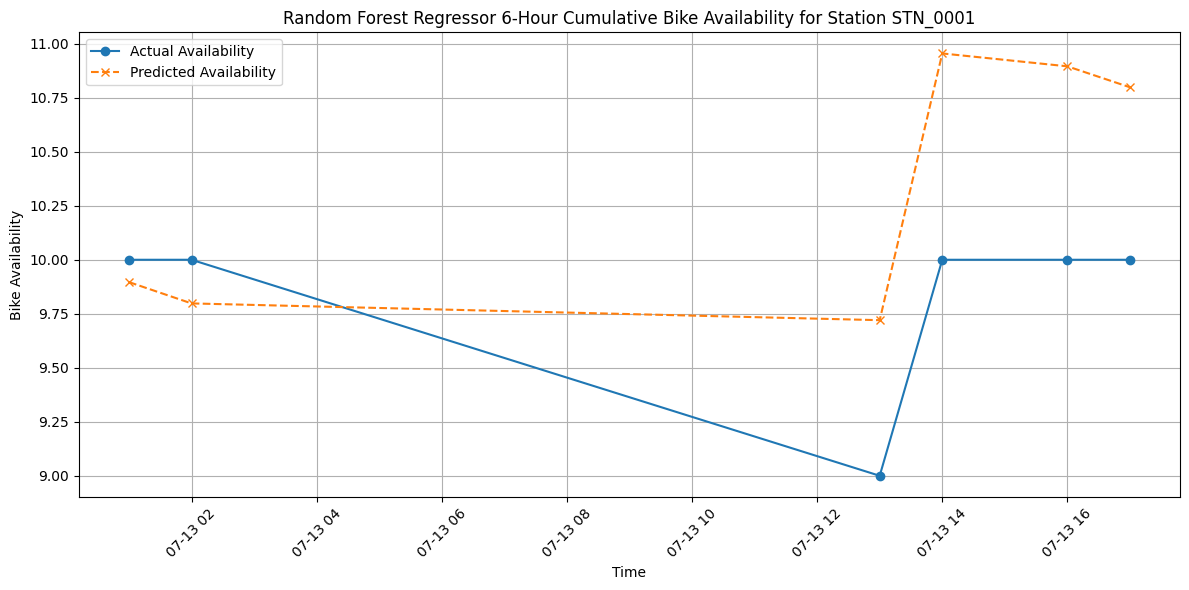

In [42]:

# Pick a sample station
sample_station = test_df.select("canonical_station_id").first()[0]

# Get the first 6 hours of the test set for this station
forecast_6hr_df_rf = combined_eval_rf.filter(F.col("canonical_station_id") == sample_station) \
    .orderBy("hour_timestamp") \
    .limit(6) \
    .toPandas()

# Starting availability
initial_availability = 10

# Compute cumulative actual availability
forecast_6hr_df_rf["actual_availability"] = initial_availability + forecast_6hr_df_rf["net_flow"].cumsum()

# Compute cumulative predicted availability
forecast_6hr_df_rf["predicted_availability"] = initial_availability + forecast_6hr_df_rf["prediction"].cumsum()

# Plot
plt.figure(figsize=(12, 6))
plt.plot(forecast_6hr_df_rf['hour_timestamp'], forecast_6hr_df_rf['actual_availability'],
         label='Actual Availability', marker='o')
plt.plot(forecast_6hr_df_rf['hour_timestamp'], forecast_6hr_df_rf['predicted_availability'],
         label='Predicted Availability', linestyle='--', marker='x')

plt.title(f'Random Forest Regressor 6-Hour Cumulative Bike Availability for Station {sample_station}')
plt.xlabel('Time')
plt.ylabel('Bike Availability')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Try Decision Trees Generalized Lienar Regression (Poisson) too

In [43]:

print("--- Training Decision Tree Models ---")
# Decision Tree for Outflow
dt_out = DecisionTreeRegressor(featuresCol='features', labelCol='departures')
dt_model_out = dt_out.fit(train_data)

# Decision Tree for Inflow
dt_in = DecisionTreeRegressor(featuresCol='features', labelCol='arrivals')
dt_model_in = dt_in.fit(train_data)

# Predictions
pred_out_dt = dt_model_out.transform(test_data)
pred_in_dt = dt_model_in.transform(test_data)

print("DT Outflow - RMSE:", eval_rmse.setLabelCol('departures').evaluate(pred_out_dt))
print("DT Inflow  - RMSE:", eval_rmse.setLabelCol('arrivals').evaluate(pred_in_dt))

--- Training Decision Tree Models ---
DT Outflow - RMSE: 0.788396698319191
DT Inflow  - RMSE: 0.8563779865598079


In [44]:


print("--- Training Poisson GLR Models ---")
# GLR for Outflow
gl_out = GeneralizedLinearRegression(family="poisson", link="log", featuresCol='features', labelCol='departures', maxIter=10)
gl_model_out = gl_out.fit(train_data)

# GLR for Inflow
gl_in = GeneralizedLinearRegression(family="poisson", link="log", featuresCol='features', labelCol='arrivals', maxIter=10)
gl_model_in = gl_in.fit(train_data)

# Predictions
pred_out_gl = gl_model_out.transform(test_data)
pred_in_gl = gl_model_in.transform(test_data)

print("GLR Poisson Outflow - RMSE:", eval_rmse.setLabelCol('departures').evaluate(pred_out_gl))
print("GLR Poisson Inflow  - RMSE:", eval_rmse.setLabelCol('arrivals').evaluate(pred_in_gl))

--- Training Poisson GLR Models ---
GLR Poisson Outflow - RMSE: 0.8431275869947916
GLR Poisson Inflow  - RMSE: 0.8855479131572878


In [45]:
show_all_importance(dt_model_out, "DT Outflow")
show_all_importance(dt_out, "DT Inflow")

show_all_importance(gl_model_out, "GLR Poisson Outflow")
show_all_importance(gl_model_in, "GLR Poisson Inflow")


--- DT Outflow Model Weights/Importance ---
avg_congestion_ratio          : 0.668589
arrivals_lag1                 : 0.230115
daily_ride_count              : 0.076961
hour                          : 0.015973
net_flow_lag12                : 0.008363
dist_to_nearest_transit       : 0.000000
stops_within_200m             : 0.000000
stops_within_500m             : 0.000000
stops_within_1km              : 0.000000
day_of_week                   : 0.000000
month                         : 0.000000
is_weekend                    : 0.000000
capacity                      : 0.000000
monthly_ride_count            : 0.000000
weather_temperature           : 0.000000
weather_precipitation         : 0.000000
departures_lag1               : 0.000000
net_flow_lag1                 : 0.000000
arrivals_lag2                 : 0.000000
departures_lag2               : 0.000000
net_flow_lag2                 : 0.000000
arrivals_lag4                 : 0.000000
departures_lag4               : 0.000000
net_flow_lag

In [46]:
import pandas as pd

def get_metrics(pred, label):
    return [
        eval_rmse.setLabelCol(label).evaluate(pred),
        eval_mae.setLabelCol(label).evaluate(pred),
        eval_r2.setLabelCol(label).evaluate(pred)
    ]

results = [
    ['GBT', 'Outflow'] + get_metrics(pred_out, 'departures'),
    ['GBT', 'Inflow'] + get_metrics(pred_in, 'arrivals'),
    ['LR', 'Outflow'] + get_metrics(pred_out_lr, 'departures'),
    ['LR', 'Inflow'] + get_metrics(pred_in_lr, 'arrivals'),
    ['RF', 'Outflow'] + get_metrics(pred_out_rf, 'departures'),
    ['RF', 'Inflow'] + get_metrics(pred_in_rf, 'arrivals'),
    ['DT', 'Outflow'] + get_metrics(pred_out_dt, 'departures'),
    ['DT', 'Inflow'] + get_metrics(pred_in_dt, 'arrivals'),
    ['GL', 'Outflow'] + get_metrics(pred_out_gl, 'departures'),
    ['GL', 'Inflow'] + get_metrics(pred_in_gl, 'arrivals')
]

summary_df = pd.DataFrame(results, columns=['Model', 'Target', 'RMSE', 'MAE', 'R2'])
display(summary_df)

,Model,Target,RMSE,MAE,R2
0,GBT,Outflow,0.794231,0.486503,0.303610
1,GBT,Inflow,0.847854,0.539749,0.196377
2,LR,Outflow,0.848293,0.597991,0.205580
3,LR,Inflow,0.891564,0.624259,0.111382
4,RF,Outflow,0.829456,0.515263,0.240470
5,RF,Inflow,0.918971,0.584607,0.055910
6,DT,Outflow,0.788397,0.483740,0.313804
7,DT,Inflow,0.856378,0.552725,0.180137
8,GL,Outflow,0.843128,0.588808,0.215225
9,GL,Inflow,0.885548,0.620516,0.123334


Decision Tree Regressor Prediction Graph

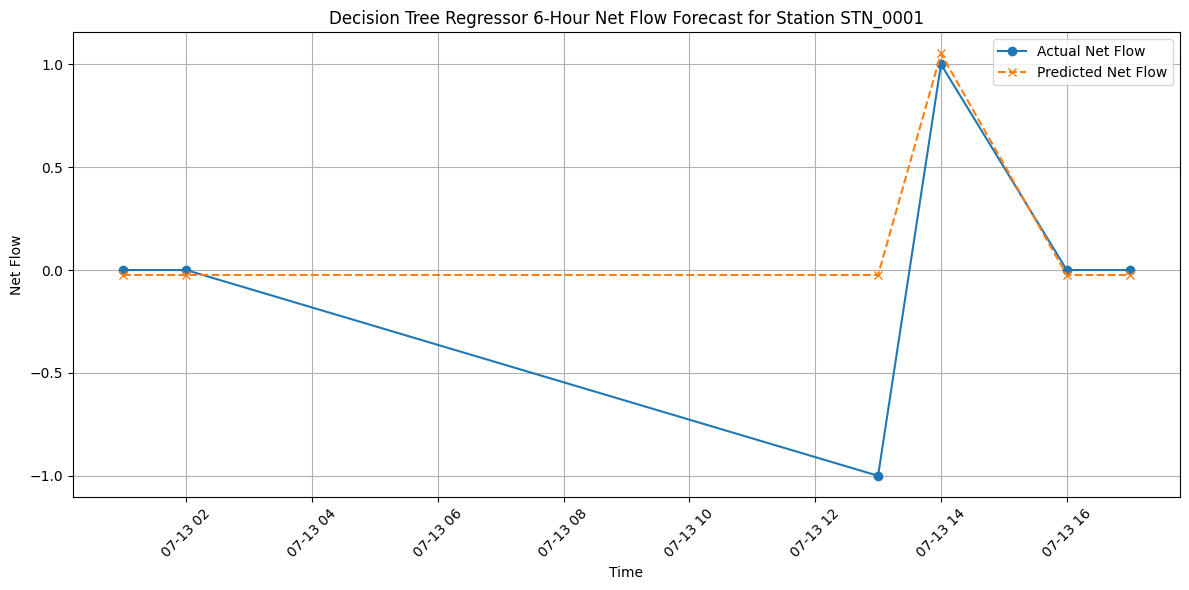

In [47]:

# Fix Ambiguous Reference by selecting unique columns from each side before join
pred_out_dt_sel = pred_out_dt.select("canonical_station_id", "hour_timestamp", "departures", F.col("prediction").alias("pred_out_dt"))
pred_in_dt_sel = pred_in_dt.select("canonical_station_id", "hour_timestamp", "arrivals", F.col("prediction").alias("pred_in_dt"))

combined_eval_dt = pred_out_dt_sel.join(pred_in_dt_sel, on=["canonical_station_id", "hour_timestamp"])
combined_eval_dt = combined_eval_dt.withColumn("net_flow", F.col("arrivals") - F.col("departures")) \
                             .withColumn("prediction", F.col("pred_in_dt") - F.col("pred_out_dt"))

# Pick a sample station and a specific start time from the test set
sample_station = test_df.select("canonical_station_id").first()[0]
# Get the first 6 hours of the test set for this station
forecast_6hr_df_dt = combined_eval_dt.filter(F.col("canonical_station_id") == sample_station) \
    .orderBy("hour_timestamp") \
    .limit(6) \
    .toPandas()

plt.figure(figsize=(12, 6))
plt.plot(forecast_6hr_df_dt['hour_timestamp'], forecast_6hr_df_dt['net_flow'], label='Actual Net Flow', marker='o')
plt.plot(forecast_6hr_df_dt['hour_timestamp'], forecast_6hr_df_dt['prediction'], label='Predicted Net Flow', linestyle='--', marker='x')

plt.title(f'Decision Tree Regressor 6-Hour Net Flow Forecast for Station {sample_station}')
plt.xlabel('Time')
plt.ylabel('Net Flow')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [48]:

# 1. Define window partitioned by station and ordered by time
window_spec = Window.partitionBy("canonical_station_id").orderBy("hour_timestamp")

# Join combined_eval with clean_resolver_df to get capacity
# Make sure to select only necessary columns to avoid duplication and keep the DataFrame tidy
combined_eval_with_capacity_dt = combined_eval_dt.join(
    clean_resolver_df.select("canonical_station_id", "capacity"),
    on="canonical_station_id",
    how="left"
)

# 2. Calculate cumulative net flow (Predicted Inventory Change)
# We use the 'prediction' column from our GBT model to forecast future state
predictions_with_inventory_dt = combined_eval_with_capacity_dt.withColumn(
    "cumulative_net_flow_forecast",
    F.sum("prediction").over(window_spec)
)

# 3. Define a starting point (Initial Bikes)
# In a real scenario, this would be the current 'num_bikes_available'
# For this simulation, let's assume stations start at 50% capacity
predictions_with_inventory_dt = predictions_with_inventory_dt.withColumn(
    "predicted_bikes_available",
    (F.col("capacity") * 0.5) + F.col("cumulative_net_flow_forecast")
)

# 4. Create Refill Flag (e.g., if predicted bikes drop below 10% of capacity)
predictions_with_inventory_dt = predictions_with_inventory_dt.withColumn(
    "refill_required_flag",
    F.when(F.col("predicted_bikes_available") < (F.col("capacity") * 0.1), 1).otherwise(0)
)

print("Cumulative flow and refill flags calculated.")
predictions_with_inventory_dt.select(
    "canonical_station_id",
    "hour_timestamp",
    "prediction",
    "predicted_bikes_available",
    "refill_required_flag"
).show(10)

Cumulative flow and refill flags calculated.
+--------------------+-------------------+--------------------+-------------------------+--------------------+
|canonical_station_id|     hour_timestamp|          prediction|predicted_bikes_available|refill_required_flag|
+--------------------+-------------------+--------------------+-------------------------+--------------------+
|            STN_0001|2025-07-13 01:00:00|-0.02406374501992037|        19.47593625498008|                   0|
|            STN_0001|2025-07-13 02:00:00|-0.02406374501992037|        19.45187250996016|                   0|
|            STN_0001|2025-07-13 13:00:00|-0.02406374501992037|       19.427808764940238|                   0|
|            STN_0001|2025-07-13 14:00:00|  1.0526315789473684|       20.480440343887608|                   0|
|            STN_0001|2025-07-13 16:00:00|-0.02406374501992037|        20.45637659886769|                   0|
|            STN_0001|2025-07-13 17:00:00|-0.02406374501992037|    

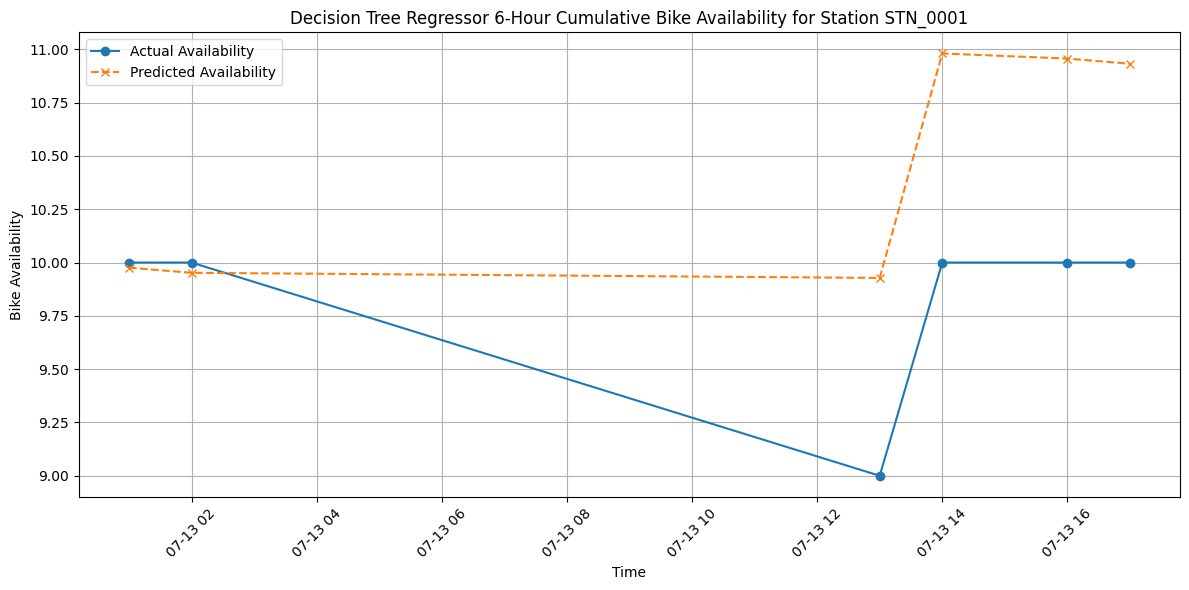

In [49]:

# Pick a sample station
sample_station = test_df.select("canonical_station_id").first()[0]

# Get the first 6 hours of the test set for this station
forecast_6hr_df_dt = combined_eval_dt.filter(F.col("canonical_station_id") == sample_station) \
    .orderBy("hour_timestamp") \
    .limit(6) \
    .toPandas()

# Starting availability
initial_availability = 10

# Compute cumulative actual availability
forecast_6hr_df_dt["actual_availability"] = initial_availability + forecast_6hr_df_dt["net_flow"].cumsum()

# Compute cumulative predicted availability
forecast_6hr_df_dt["predicted_availability"] = initial_availability + forecast_6hr_df_dt["prediction"].cumsum()

# Plot
plt.figure(figsize=(12, 6))
plt.plot(forecast_6hr_df_dt['hour_timestamp'], forecast_6hr_df_dt['actual_availability'],
         label='Actual Availability', marker='o')
plt.plot(forecast_6hr_df_dt['hour_timestamp'], forecast_6hr_df_dt['predicted_availability'],
         label='Predicted Availability', linestyle='--', marker='x')

plt.title(f'Decision Tree Regressor 6-Hour Cumulative Bike Availability for Station {sample_station}')
plt.xlabel('Time')
plt.ylabel('Bike Availability')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Generalized Linear Regressor (Poisson) Prediction Graph




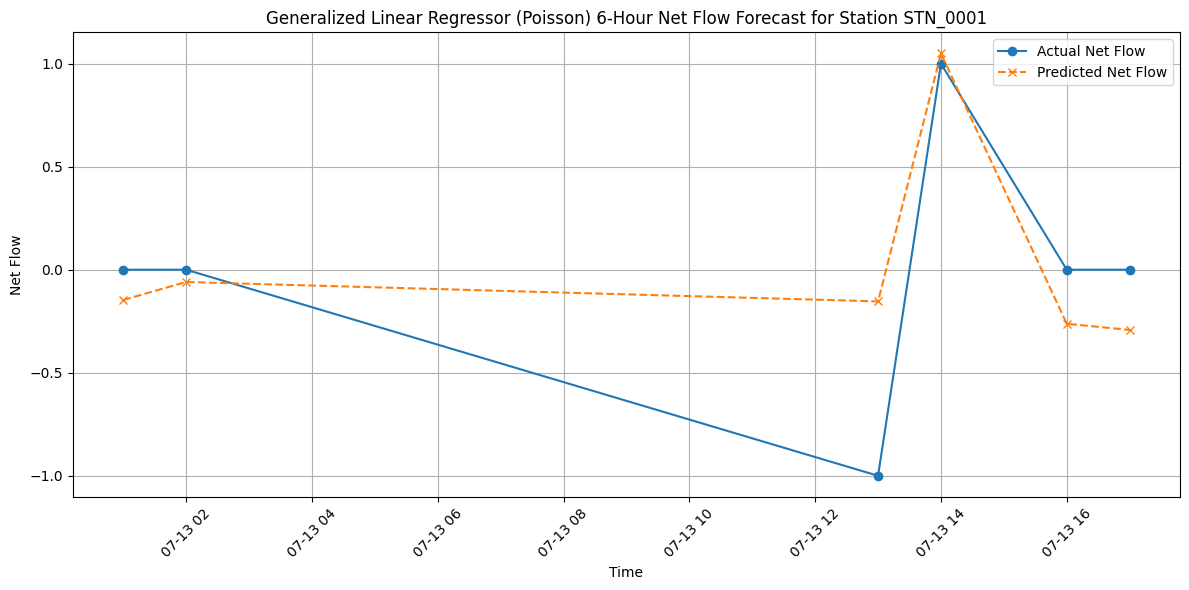

In [50]:

# Fix Ambiguous Reference by selecting unique columns from each side before join
pred_out_gl_sel = pred_out_gl.select("canonical_station_id", "hour_timestamp", "departures", F.col("prediction").alias("pred_out_gl"))
pred_in_gl_sel = pred_in_gl.select("canonical_station_id", "hour_timestamp", "arrivals", F.col("prediction").alias("pred_in_gl"))

combined_eval_gl = pred_out_gl_sel.join(pred_in_gl_sel, on=["canonical_station_id", "hour_timestamp"])
combined_eval_gl = combined_eval_gl.withColumn("net_flow", F.col("arrivals") - F.col("departures")) \
                             .withColumn("prediction", F.col("pred_in_gl") - F.col("pred_out_gl"))

# Pick a sample station and a specific start time from the test set
sample_station = test_df.select("canonical_station_id").first()[0]
# Get the first 6 hours of the test set for this station
forecast_6hr_df_gl = combined_eval_gl.filter(F.col("canonical_station_id") == sample_station) \
    .orderBy("hour_timestamp") \
    .limit(6) \
    .toPandas()

plt.figure(figsize=(12, 6))
plt.plot(forecast_6hr_df_gl['hour_timestamp'], forecast_6hr_df_gl['net_flow'], label='Actual Net Flow', marker='o')
plt.plot(forecast_6hr_df_gl['hour_timestamp'], forecast_6hr_df_gl['prediction'], label='Predicted Net Flow', linestyle='--', marker='x')

plt.title(f'Generalized Linear Regressor (Poisson) 6-Hour Net Flow Forecast for Station {sample_station}')
plt.xlabel('Time')
plt.ylabel('Net Flow')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [51]:

# 1. Define window partitioned by station and ordered by time
window_spec = Window.partitionBy("canonical_station_id").orderBy("hour_timestamp")

# Join combined_eval with clean_resolver_df to get capacity
# Make sure to select only necessary columns to avoid duplication and keep the DataFrame tidy
combined_eval_with_capacity_gl = combined_eval_dt.join(
    clean_resolver_df.select("canonical_station_id", "capacity"),
    on="canonical_station_id",
    how="left"
)

# 2. Calculate cumulative net flow (Predicted Inventory Change)
# We use the 'prediction' column from our GBT model to forecast future state
predictions_with_inventory_gl = combined_eval_with_capacity_gl.withColumn(
    "cumulative_net_flow_forecast",
    F.sum("prediction").over(window_spec)
)

# 3. Define a starting point (Initial Bikes)
# In a real scenario, this would be the current 'num_bikes_available'
# For this simulation, let's assume stations start at 50% capacity
predictions_with_inventory_gl = predictions_with_inventory_gl.withColumn(
    "predicted_bikes_available",
    (F.col("capacity") * 0.5) + F.col("cumulative_net_flow_forecast")
)

# 4. Create Refill Flag (e.g., if predicted bikes drop below 10% of capacity)
predictions_with_inventory_gl = predictions_with_inventory_gl.withColumn(
    "refill_required_flag",
    F.when(F.col("predicted_bikes_available") < (F.col("capacity") * 0.1), 1).otherwise(0)
)

print("Cumulative flow and refill flags calculated.")
predictions_with_inventory_gl.select(
    "canonical_station_id",
    "hour_timestamp",
    "prediction",
    "predicted_bikes_available",
    "refill_required_flag"
).show(10)

Cumulative flow and refill flags calculated.
+--------------------+-------------------+--------------------+-------------------------+--------------------+
|canonical_station_id|     hour_timestamp|          prediction|predicted_bikes_available|refill_required_flag|
+--------------------+-------------------+--------------------+-------------------------+--------------------+
|            STN_0001|2025-07-13 01:00:00|-0.02406374501992037|        19.47593625498008|                   0|
|            STN_0001|2025-07-13 02:00:00|-0.02406374501992037|        19.45187250996016|                   0|
|            STN_0001|2025-07-13 13:00:00|-0.02406374501992037|       19.427808764940238|                   0|
|            STN_0001|2025-07-13 14:00:00|  1.0526315789473684|       20.480440343887608|                   0|
|            STN_0001|2025-07-13 16:00:00|-0.02406374501992037|        20.45637659886769|                   0|
|            STN_0001|2025-07-13 17:00:00|-0.02406374501992037|    

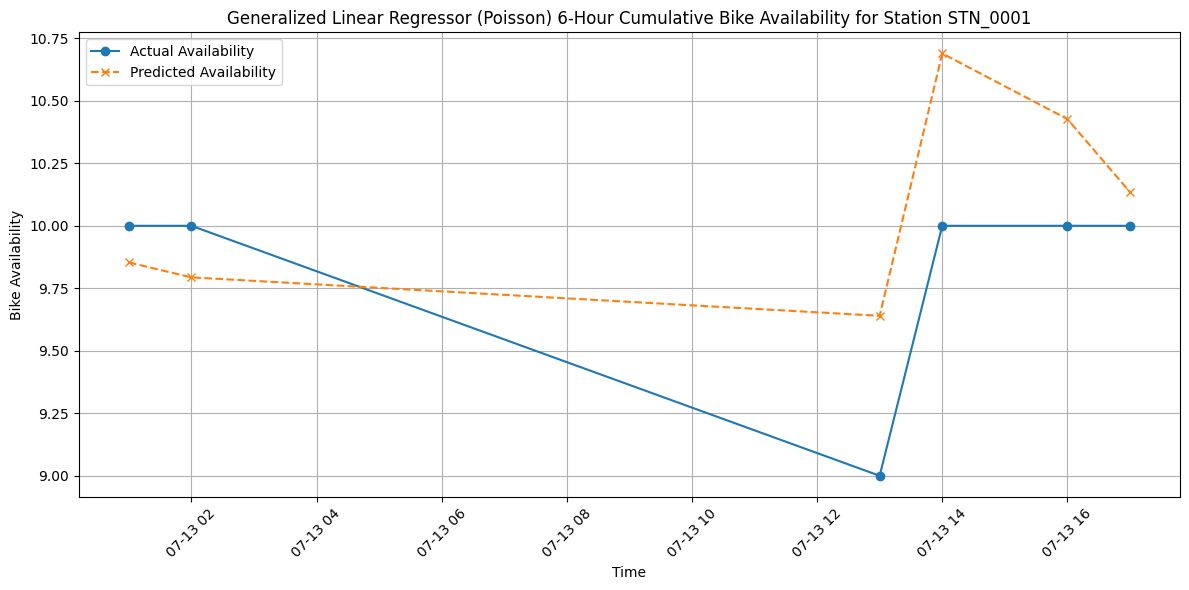

In [52]:

# Pick a sample station
sample_station = test_df.select("canonical_station_id").first()[0]

# Get the first 6 hours of the test set for this station
forecast_6hr_df_gl = combined_eval_gl.filter(F.col("canonical_station_id") == sample_station) \
    .orderBy("hour_timestamp") \
    .limit(6) \
    .toPandas()

# Starting availability
initial_availability = 10

# Compute cumulative actual availability
forecast_6hr_df_gl["actual_availability"] = initial_availability + forecast_6hr_df_gl["net_flow"].cumsum()

# Compute cumulative predicted availability
forecast_6hr_df_gl["predicted_availability"] = initial_availability + forecast_6hr_df_gl["prediction"].cumsum()

# Plot
plt.figure(figsize=(12, 6))
plt.plot(forecast_6hr_df_gl['hour_timestamp'], forecast_6hr_df_gl['actual_availability'],
         label='Actual Availability', marker='o')
plt.plot(forecast_6hr_df_gl['hour_timestamp'], forecast_6hr_df_gl['predicted_availability'],
         label='Predicted Availability', linestyle='--', marker='x')

plt.title(f'Generalized Linear Regressor (Poisson) 6-Hour Cumulative Bike Availability for Station {sample_station}')
plt.xlabel('Time')
plt.ylabel('Bike Availability')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()